In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
Caro = pd.read_excel("/content/drive/MyDrive/Proyecto Zanahoria/Muestreos/Carotenoides/Completo_carotenoides.xlsx", sheet_name=" Curva")
Caro


,Solucion,Abs450nm
0,0ppm,0.004
1,1ppm,0.099
2,10ppm,0.173
3,100ppm,0.545
4,1000ppm,4.165


In [ ]:
Caro["Solucion"]=Caro["Solucion"].replace({"0ppm":0,"1ppm":1,"10ppm":10,"100ppm":100,"1000ppm":1000})

In [ ]:
Caro

,Solucion,Abs450nm
0,0,0.004
1,1,0.099
2,10,0.173
3,100,0.545
4,1000,4.165


<Axes: xlabel='Abs450nm', ylabel='Solucion'>

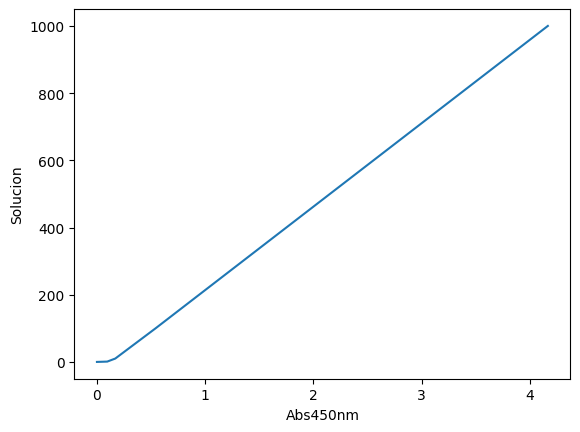

In [ ]:
sns.lineplot(data=Caro, x="Abs450nm",y="Solucion")

In [ ]:
model = LinearRegression()
model.fit(Caro['Abs450nm'].values.reshape((-1, 1)), Caro['Solucion'].values)
b = model.intercept_
m = model.coef_[0]
print(f'Y = {round(m,3)}x {round(b,3)}')

Y = 244.922x -22.036


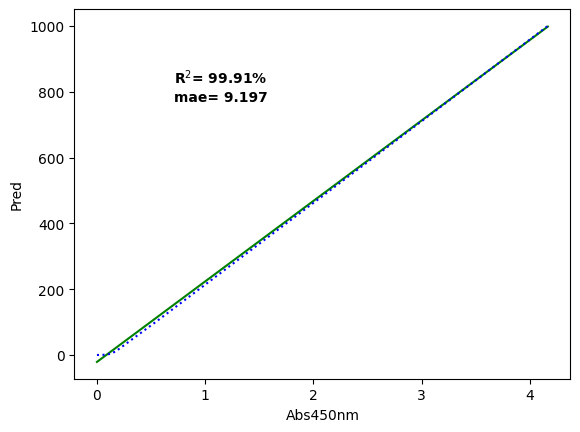

In [ ]:
Caro['Pred'] = Caro['Abs450nm'].apply(lambda x: m*x +b)
r = round(r2_score(Caro['Solucion'], Caro['Pred'])*100,3)
mae = round(mean_absolute_error(Caro['Solucion'], Caro['Pred']),3)
sns.lineplot(data=Caro, x="Abs450nm",y="Pred",color='green')
sns.lineplot(data=Caro, x="Abs450nm",y="Solucion",color='blue',linestyle='dotted')
plt.text(0.2, 0.75, f'mae= {mae}', transform=plt.gca().transAxes,fontweight='bold')
plt.text(0.2, 0.8, 'R'r'$^{2}$' f'= {r}%', transform=plt.gca().transAxes,fontweight='bold')
plt.show()

In [ ]:
Caro

,Solucion,Abs450nm,Pred
0,0,0.004,-21.056680
1,1,0.099,2.210924
2,10,0.173,20.335163
3,100,0.545,111.446203
4,1000,4.165,998.064389


In [ ]:
REFRI_primer= pd.read_excel(r"/content/drive/MyDrive/Colab Notebooks/Espectral/Data/Carotenoides.xlsx", sheet_name="REFRI_09")
Tam_primer= pd.read_excel(r"/content/drive/MyDrive/Colab Notebooks/Espectral/Data/Carotenoides.xlsx", sheet_name="AMB_09")
Tam_primer.columns

Index(['Material', 'Replica', 'Absorbancia1 450nm', 'Absorbancia2 450nm',
       'Absorbancia3 450nm'],
      dtype='object')

In [ ]:
Tam_primer.columns = ['Material', 'Replica', 'AbsorbanciaTam', 'AbsorbanciaTam2','AbsorbanciaTam3']
REFRI_primer.columns = ['Material', 'Replica', 'AbsorbanciaRefri', 'AbsorbanciaRefri2','AbsorbanciaRefri3']

In [ ]:
T1=pd.concat([REFRI_primer[['Material', 'Replica', 'AbsorbanciaRefri']],Tam_primer[['AbsorbanciaTam']]],axis=1)
T1["ppmRefri"]=T1['AbsorbanciaRefri'].apply(lambda x: m*x +b)
T1["ppmTam"]=T1['AbsorbanciaTam'].apply(lambda x: m*x +b)
T1["ppmRefri"].loc[T1["ppmRefri"]<0]=0
T1["ppmTam"].loc[T1["ppmTam"]<0]=0

In [ ]:
T2=pd.concat([REFRI_primer[['Material', 'Replica', 'AbsorbanciaRefri2']],Tam_primer[['AbsorbanciaTam2']]],axis=1)
T2["ppmRefri"]=T2['AbsorbanciaRefri2'].apply(lambda x: m*x +b)
T2["ppmTam"]=T2['AbsorbanciaTam2'].apply(lambda x: m*x +b)
T2["ppmRefri"].loc[T2["ppmRefri"]<0]=0
T2["ppmTam"].loc[T2["ppmTam"]<0]=0

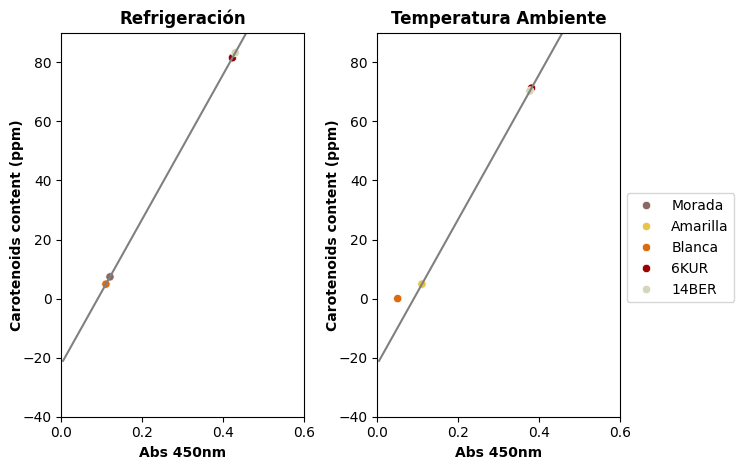

In [ ]:
plt.subplot(1,2,1)
sns.lineplot(data=Caro, x="Abs450nm",y="Pred",color='gray')
sns.scatterplot(data=T1, x='AbsorbanciaRefri',y="ppmRefri",hue="Material",legend=False, palette=['#896866', '#E7C549', '#DA6B0F', '#990000', '#D5D6B8', '#764F00'])
plt.title("Refrigeración",fontweight='bold')
plt.ylim(-40,90)
plt.xlim(0,0.6)
plt.ylabel("Carotenoids content (ppm)", labelpad=-1,fontweight='bold')
plt.xlabel("Abs 450nm",fontweight='bold')
plt.tight_layout(w_pad=4.5)

plt.subplot(1,2,2)
sns.lineplot(data=Caro, x="Abs450nm",y="Pred",color='gray')
sns.scatterplot(data=T1, x='AbsorbanciaTam',y="ppmTam",hue="Material", palette=['#896866', '#E7C549', '#DA6B0F', '#990000', '#D5D6B8', '#764F00'])
plt.title("Temperatura Ambiente",fontweight='bold')
plt.ylim(-40,90)
plt.xlim(0,0.6)
plt.ylabel("Carotenoids content (ppm)", labelpad=-1,fontweight='bold')
plt.xlabel("Abs 450nm",fontweight='bold')
plt.legend(loc='best', bbox_to_anchor=(0.5, 0., 1, 0.6))

plt.show()

<Axes: title={'center': 'Ambiente primera semana'}, xlabel='Material', ylabel='ppmTam'>

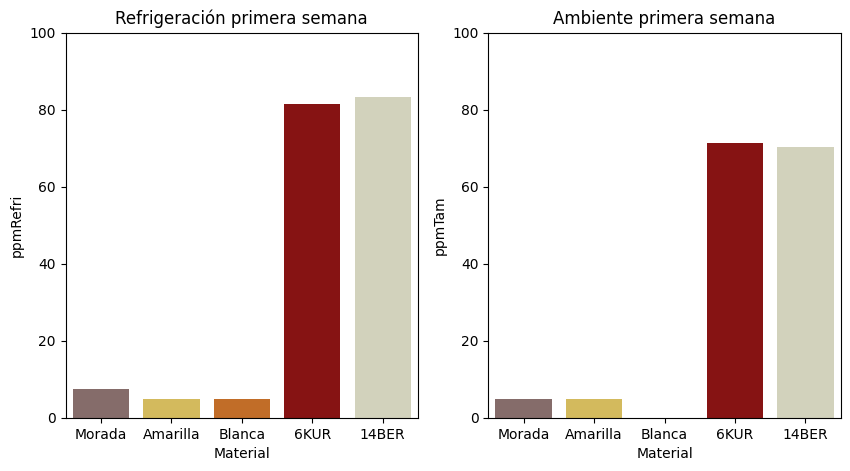

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.barplot(y='ppmRefri',x='Material',data=T1,palette=['#896866', '#E7C549', '#DA6B0F', '#990000', '#D5D6B8', '#764F00'])
plt.ylim(0,100)
plt.title('Refrigeración primera semana')

plt.subplot(1,2,2)
plt.title('Ambiente primera semana')
plt.ylim(0,100)
sns.barplot(y='ppmTam',x='Material',data=T1,palette=['#896866', '#E7C549', '#DA6B0F', '#990000', '#D5D6B8', '#764F00'])

In [ ]:
# Exportar T1 a un archivo CSV
T1.to_csv("/content/drive/MyDrive/Zanahoria/HPLC/Semana1_concentraciones.csv", index=False, encoding='utf-8')



In [ ]:
REFRI_2= pd.read_excel(r"/content/drive/MyDrive/Colab Notebooks/Espectral/Data/Carotenoides.xlsx", sheet_name="REFRI_16")
Tam_2= pd.read_excel(r"/content/drive/MyDrive/Colab Notebooks/Espectral/Data/Carotenoides.xlsx", sheet_name="AMB_16")

In [ ]:
Tam_2.columns = ['Material', 'Replica', 'AbsorbanciaTam', 'AbsorbanciaTam2','AbsorbanciaTam3']
REFRI_2.columns = ['Material', 'Replica', 'AbsorbanciaRefri', 'AbsorbanciaRefri2','AbsorbanciaRefri3']

In [ ]:
T11=pd.concat([REFRI_2[['Material', 'Replica', 'AbsorbanciaRefri']],Tam_2[['AbsorbanciaTam']]],axis=1)
T11["ppmRefri"]=T11['AbsorbanciaRefri'].apply(lambda x: m*x +b)
T11["ppmTam"]=T11['AbsorbanciaTam'].apply(lambda x: m*x +b)
T11["ppmRefri"].loc[T11["ppmRefri"]<0]=0
T11["ppmTam"].loc[T11["ppmTam"]<0]=0

<Axes: title={'center': 'Ambiente Segunda semana'}, xlabel='Material', ylabel='ppmTam'>

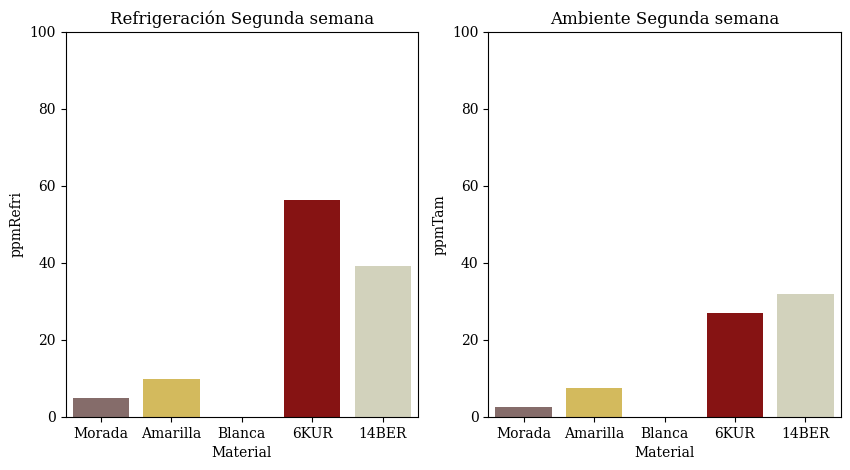

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.barplot(y='ppmRefri',x='Material',data=T11,palette=['#896866', '#E7C549', '#DA6B0F', '#990000', '#D5D6B8', '#764F00'])
plt.ylim(0,100)
plt.title('Refrigeración Segunda semana')

plt.subplot(1,2,2)
plt.title('Ambiente Segunda semana')
plt.ylim(0,100)
sns.barplot(y='ppmTam',x='Material',data=T11,palette=['#896866', '#E7C549', '#DA6B0F', '#990000', '#D5D6B8', '#764F00'])

In [ ]:
# Exportar T1 a un archivo CSV
T11.to_csv("/content/drive/MyDrive/Zanahoria/HPLC/Semana2_concentraciones.csv", index=False, encoding='utf-8')


In [ ]:
REFRI_3= pd.read_excel(r"/content/drive/MyDrive/Colab Notebooks/Espectral/Data/Carotenoides.xlsx", sheet_name="REFRI_23")
Tam_3= pd.read_excel(r"/content/drive/MyDrive/Colab Notebooks/Espectral/Data/Carotenoides.xlsx", sheet_name="AMB_23")

In [ ]:
Tam_3.columns = ['Material', 'Replica', 'AbsorbanciaTam', 'AbsorbanciaTam2','AbsorbanciaTam3']
REFRI_3.columns = ['Material', 'Replica', 'AbsorbanciaRefri', 'AbsorbanciaRefri2','AbsorbanciaRefri3']

In [ ]:
T12=pd.concat([REFRI_3[['Material', 'Replica', 'AbsorbanciaRefri']],Tam_3[['AbsorbanciaTam']]],axis=1)
T12["ppmRefri"]=T12['AbsorbanciaRefri'].apply(lambda x: m*x +b)
T12["ppmTam"]=T12['AbsorbanciaTam'].apply(lambda x: m*x +b)
T12["ppmRefri"].loc[T12["ppmRefri"]<0]=0
T12["ppmTam"].loc[T12["ppmTam"]<0]=0

<Axes: title={'center': 'Ambiente Tercera semana'}, xlabel='Material', ylabel='ppmTam'>

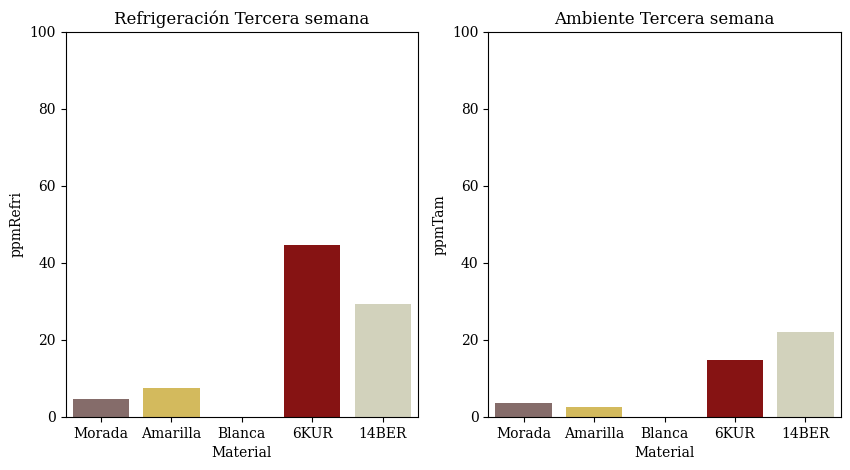

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.barplot(y='ppmRefri',x='Material',data=T12,palette=['#896866', '#E7C549', '#DA6B0F', '#990000', '#D5D6B8', '#764F00'])
plt.ylim(0,100)
plt.title('Refrigeración Tercera semana')

plt.subplot(1,2,2)
plt.title('Ambiente Tercera semana')
plt.ylim(0,100)
sns.barplot(y='ppmTam',x='Material',data=T12,palette=['#896866', '#E7C549', '#DA6B0F', '#990000', '#D5D6B8', '#764F00'])

In [ ]:
# Exportar T1 a un archivo CSV
T12.to_csv("/content/drive/MyDrive/Zanahoria/HPLC/Semana3_concentraciones.csv", index=False, encoding='utf-8')


In [ ]:
REFRI_4= pd.read_excel(r"/content/drive/MyDrive/Colab Notebooks/Espectral/Data/Carotenoides.xlsx", sheet_name="REFRI_30")
Tam_4= pd.read_excel(r"/content/drive/MyDrive/Colab Notebooks/Espectral/Data/Carotenoides.xlsx", sheet_name="AMB_30")

In [ ]:
Tam_4.columns = ['Material', 'Replica', 'AbsorbanciaTam', 'AbsorbanciaTam2','AbsorbanciaTam3']
REFRI_4.columns = ['Material', 'Replica', 'AbsorbanciaRefri', 'AbsorbanciaRefri2','AbsorbanciaRefri3']

In [ ]:
T13=pd.concat([REFRI_4[['Material', 'Replica', 'AbsorbanciaRefri']],Tam_4[['AbsorbanciaTam']]],axis=1)
T13["ppmRefri"]=T13['AbsorbanciaRefri'].apply(lambda x: m*x +b)
T13["ppmTam"]=T13['AbsorbanciaTam'].apply(lambda x: m*x +b)
T13["ppmRefri"].loc[T13["ppmRefri"]<0]=0
T13["ppmTam"].loc[T13["ppmTam"]<0]=0

<Axes: title={'center': 'Ambiente Cuarta semana'}, xlabel='Material', ylabel='ppmTam'>

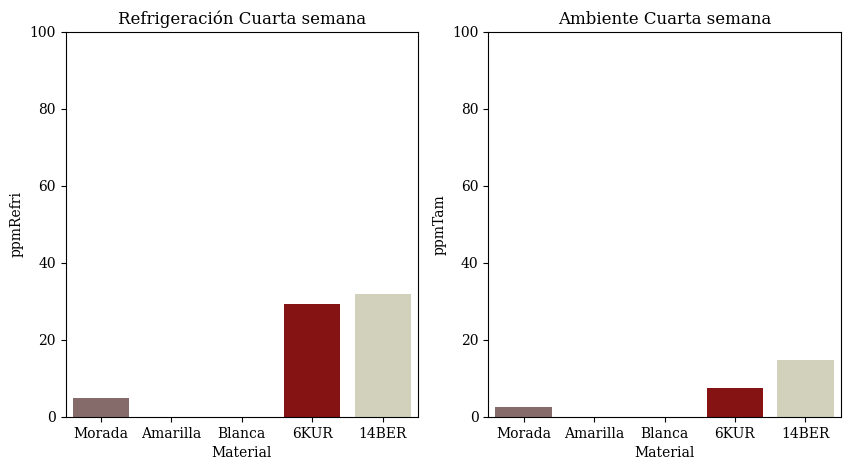

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.barplot(y='ppmRefri',x='Material',data=T13,palette=['#896866', '#E7C549', '#DA6B0F', '#990000', '#D5D6B8', '#764F00'])
plt.ylim(0,100)
plt.title('Refrigeración Cuarta semana')

plt.subplot(1,2,2)
plt.title('Ambiente Cuarta semana')
plt.ylim(0,100)
sns.barplot(y='ppmTam',x='Material',data=T13,palette=['#896866', '#E7C549', '#DA6B0F', '#990000', '#D5D6B8', '#764F00'])

In [ ]:
# Exportar T1 a un archivo CSV
T13.to_csv("/content/drive/MyDrive/Zanahoria/HPLC/Semana4_concentraciones.csv", index=False, encoding='utf-8')


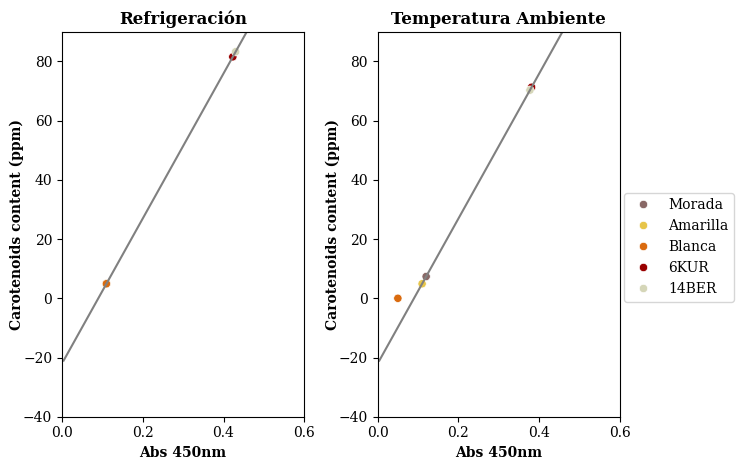

In [ ]:
plt.subplot(1,2,1)
sns.lineplot(data=Caro, x="Abs450nm",y="Pred",color='gray')
sns.scatterplot(data=T1, x='AbsorbanciaRefri',y="ppmRefri",hue="Material",legend=False, palette=['#896866', '#E7C549', '#DA6B0F', '#990000', '#D5D6B8', '#764F00'])
plt.title("Refrigeración",fontweight='bold')
plt.ylim(-40,90)
plt.xlim(0,0.6)
plt.ylabel("Carotenoids content (ppm)", labelpad=-1,fontweight='bold')
plt.xlabel("Abs 450nm",fontweight='bold')
plt.tight_layout(w_pad=4.5)

plt.subplot(1,2,2)
sns.lineplot(data=Caro, x="Abs450nm",y="Pred",color='gray')
sns.scatterplot(data=T1, x='AbsorbanciaTam',y="ppmTam",hue="Material", palette=['#896866', '#E7C549', '#DA6B0F', '#990000', '#D5D6B8', '#764F00'])
plt.title("Temperatura Ambiente",fontweight='bold')
plt.ylim(-40,90)
plt.xlim(0,0.6)
plt.ylabel("Carotenoids content (ppm)", labelpad=-1,fontweight='bold')
plt.xlabel("Abs 450nm",fontweight='bold')
plt.legend(loc='best', bbox_to_anchor=(0.5, 0., 1, 0.6))

plt.show()

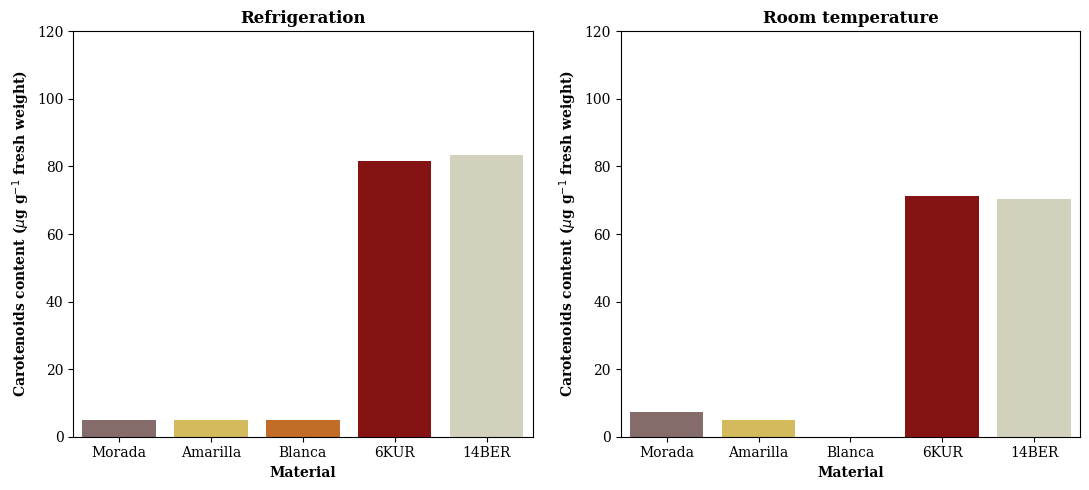

In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']


plt.figure(figsize=(11,5))
plt.subplot(1,2,1)
sns.barplot(y='ppmRefri',x='Material',data=T1, palette=['#896866', '#E7C549', '#DA6B0F', '#990000', '#D5D6B8', '#764F00'],ci=False)
plt.ylim(0,120)
plt.title('Refrigeration',fontweight='bold')
plt.ylabel("Carotenoids content ($\mu$g g$^{-1}$ fresh weight)",fontweight='bold')
plt.xlabel("Material",fontweight='bold')

plt.subplot(1,2,2)
plt.title('Room temperature',fontweight='bold')
plt.ylim(0,120)
sns.barplot(y='ppmTam',x='Material',data=T1, palette=['#896866', '#E7C549', '#DA6B0F', '#990000', '#D5D6B8', '#764F00'],ci=False)
plt.ylabel("Carotenoids content ($\mu$g g$^{-1}$ fresh weight)",fontweight='bold')
plt.xlabel("Material",fontweight='bold')
plt.tight_layout(w_pad=1.8)

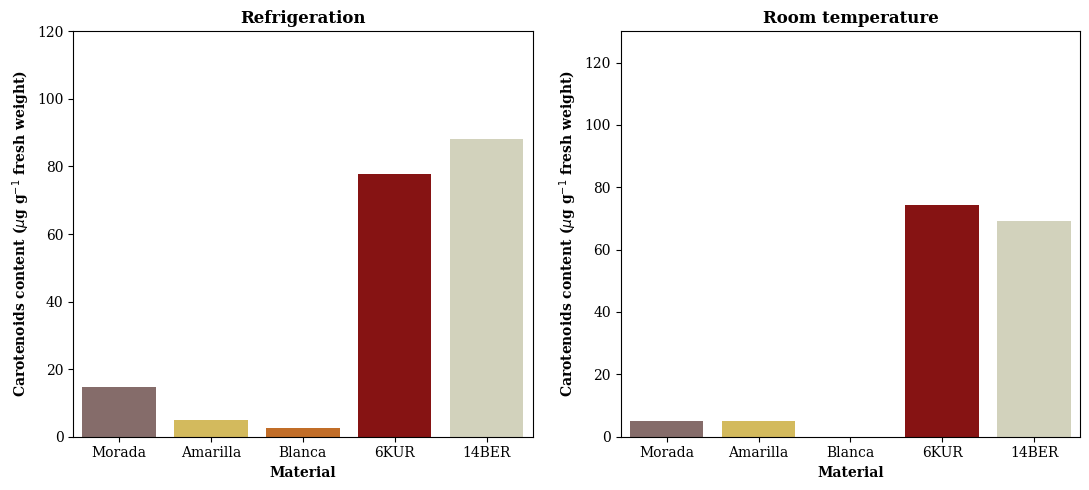

In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']


plt.figure(figsize=(11,5))
plt.subplot(1,2,1)
sns.barplot(y='ppmRefri',x='Material',data=T2, palette=['#896866', '#E7C549', '#DA6B0F', '#990000', '#D5D6B8', '#764F00'],ci=False)
plt.ylim(0,120)
plt.title('Refrigeration',fontweight='bold')
plt.ylabel("Carotenoids content ($\mu$g g$^{-1}$ fresh weight)",fontweight='bold')
plt.xlabel("Material",fontweight='bold')

plt.subplot(1,2,2)
plt.title('Room temperature',fontweight='bold')
plt.ylim(0,130)
sns.barplot(y='ppmTam',x='Material',data=T2, palette=['#896866', '#E7C549', '#DA6B0F', '#990000', '#D5D6B8', '#764F00'],ci=False)
plt.ylabel("Carotenoids content ($\mu$g g$^{-1}$ fresh weight)",fontweight='bold')
plt.xlabel("Material",fontweight='bold')
plt.tight_layout(w_pad=1.8)

NameError: name 'T3' is not defined

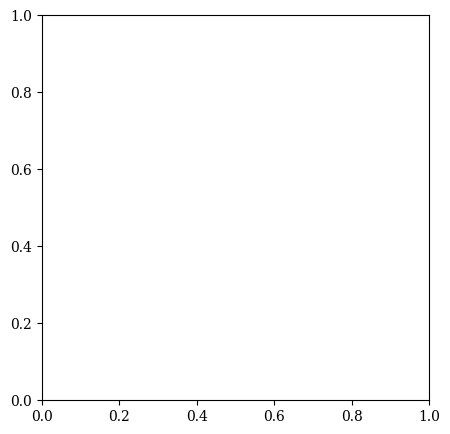

In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']


plt.figure(figsize=(11,5))
plt.subplot(1,2,1)
sns.barplot(y='ppmRefri',x='Material',data=T3, palette=['#896866', '#E7C549', '#DA6B0F', '#990000', '#D5D6B8', '#764F00'],ci=False)
plt.ylim(0,120)
plt.title('Refrigeration',fontweight='bold')
plt.ylabel("Carotenoids content ($\mu$g g$^{-1}$ fresh weight)",fontweight='bold')
plt.xlabel("Material",fontweight='bold')

plt.subplot(1,2,2)
plt.title('Room temperature',fontweight='bold')
plt.ylim(0,120)
sns.barplot(y='ppmTam',x='Material',data=T3, palette=['#896866', '#E7C549', '#DA6B0F', '#990000', '#D5D6B8', '#764F00'],ci=False)
plt.ylabel("Carotenoids content ($\mu$g g$^{-1}$ fresh weight)",fontweight='bold')
plt.xlabel("Material",fontweight='bold')
plt.tight_layout(w_pad=1.8)

In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']


plt.figure(figsize=(11,5))
plt.subplot(1,2,1)
sns.barplot(y='ppmRefri',x='Material',data=T4, palette=['#896866', '#E7C549', '#DA6B0F', '#990000', '#D5D6B8', '#764F00'],ci=False)
plt.ylim(0,13)
plt.title('Refrigeration',fontweight='bold')
plt.ylabel("Carotenoids content ($\mu$g g$^{-1}$ fresh weight)",fontweight='bold')
plt.xlabel("Material",fontweight='bold')

plt.subplot(1,2,2)
plt.title('Room temperature',fontweight='bold')
plt.ylim(0,13)
sns.barplot(y='ppmTam',x='Material',data=T4, palette=['#896866', '#E7C549', '#DA6B0F', '#990000', '#D5D6B8', '#764F00'],ci=False)
plt.ylabel("Carotenoids content ($\mu$g g$^{-1}$ fresh weight)",fontweight='bold')
plt.xlabel("Material",fontweight='bold')
plt.tight_layout(w_pad=1.8)

In [ ]:
T1["Tiempo"]=1
T1=T1[["Tiempo","Material","ppmRefri","ppmTam"]]

T2["Tiempo"]=2
T2=T2[["Tiempo","Material","ppmRefri","ppmTam"]]

T3["Tiempo"]=3
T3=T3[["Tiempo","Material","ppmRefri","ppmTam"]]

T4["Tiempo"]=4
T4=T4[["Tiempo","Material","ppmRefri","ppmTam"]]

In [ ]:
A=pd.concat([T1,T2,T3,T4],axis=0)
A

In [ ]:
A.groupby(["Tiempo","Material"]).mean()

In [ ]:
def meancaro(x):
  return f"{round(x.mean(),2)}±{round(x.std(),2)}"

A.groupby(["Tiempo","Material"]).agg(meancaro).reset_index()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


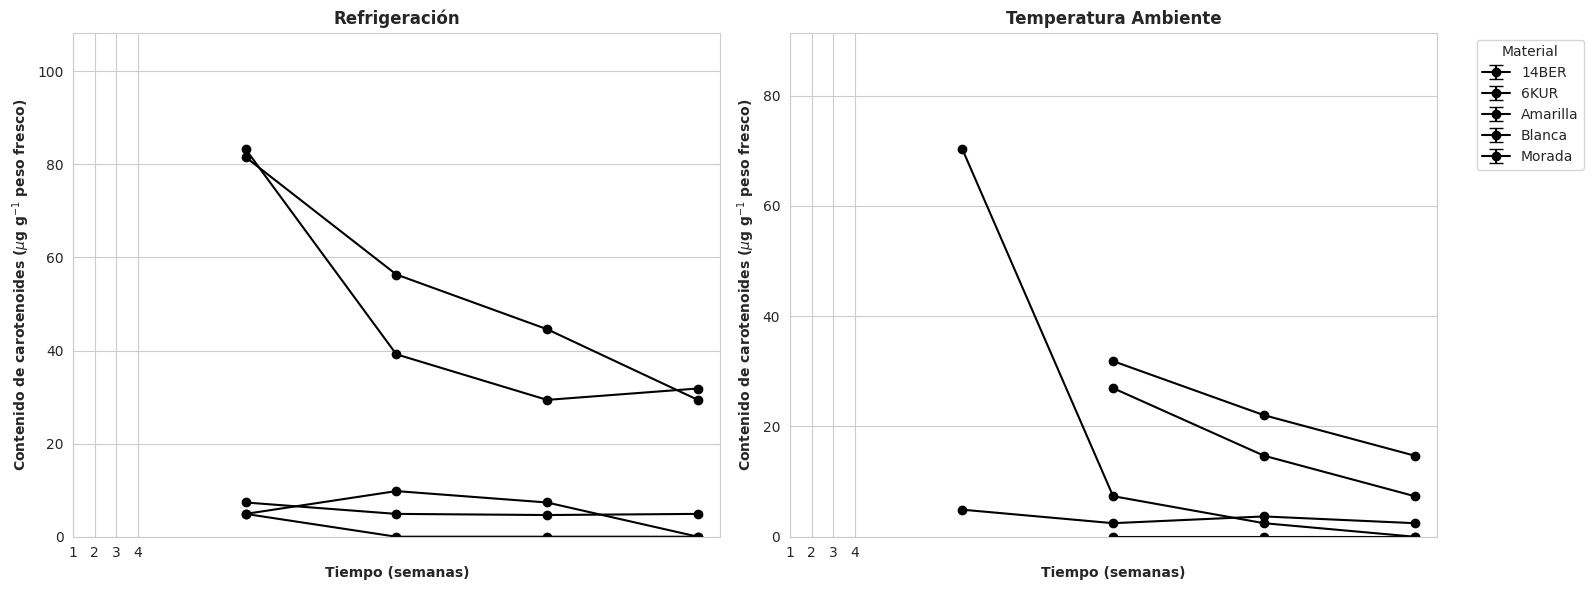

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import f_oneway
from sklearn.linear_model import LinearRegression
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Configuración de estilo
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
sns.set_style("whitegrid")

# Montar Google Drive (solo para Colab)
from google.colab import drive
drive.mount('/content/drive')

# 1. CARGAR Y PROCESAR DATOS DE CALIBRACIÓN
# ==========================================
Caro = pd.read_excel("/content/drive/MyDrive/Proyecto Zanahoria/Muestreos/Carotenoides/Completo_carotenoides.xlsx", sheet_name=" Curva")
Caro["Solucion"] = Caro["Solucion"].replace({"0ppm":0, "1ppm":1, "10ppm":10, "100ppm":100, "1000ppm":1000})

# Crear modelo de regresión lineal
model = LinearRegression()
model.fit(Caro['Abs450nm'].values.reshape((-1, 1)), Caro['Solucion'].values)
b = model.intercept_
m = model.coef_[0]
Caro['Pred'] = Caro['Abs450nm'].apply(lambda x: m*x + b)

# 2. PROCESAR DATOS EXPERIMENTALES
# ================================
def procesar_datos(semana, archivo):
    """Función para procesar datos de cada semana"""
    REFRI = pd.read_excel(archivo, sheet_name=f"REFRI_{semana}")
    Tam = pd.read_excel(archivo, sheet_name=f"AMB_{semana}")

    # Estandarizar nombres de columnas
    Tam.columns = ['Material', 'Replica', 'AbsorbanciaTam', 'AbsorbanciaTam2', 'AbsorbanciaTam3']
    REFRI.columns = ['Material', 'Replica', 'AbsorbanciaRefri', 'AbsorbanciaRefri2', 'AbsorbanciaRefri3']

    # Procesar primera medición
    T = pd.concat([REFRI[['Material', 'Replica', 'AbsorbanciaRefri']],
                   Tam[['AbsorbanciaTam']]], axis=1)
    T["ppmRefri"] = T['AbsorbanciaRefri'].apply(lambda x: m*x + b)
    T["ppmTam"] = T['AbsorbanciaTam'].apply(lambda x: m*x + b)
    T["ppmRefri"] = T["ppmRefri"].clip(lower=0)
    T["ppmTam"] = T["ppmTam"].clip(lower=0)
    T["Tiempo"] = int(semana) if isinstance(semana, str) else semana
    T["Condicion"] = "Semana_" + str(semana)

    return T[["Tiempo", "Material", "ppmRefri", "ppmTam", "Condicion"]]

# Procesar todas las semanas
archivo = "/content/drive/MyDrive/Colab Notebooks/Espectral/Data/Carotenoides.xlsx"
semanas = ["09", "16", "23", "30"]  # Ajustar según tus nombres de hoja
dfs = [procesar_datos(semana, archivo) for semana in semanas]
A = pd.concat(dfs, axis=0)

# Mapeo de materiales a colores
material_colors = {
    'Material1': '#896866',
    'Material2': '#E7C549',
    'Material3': '#DA6B0F',
    'Material4': '#990000',
    'Material5': '#D5D6B8',
    'Material6': '#764F00'
}

# 3. ANÁLISIS ESTADÍSTICO
# ========================
def analisis_estadistico(data, grupo):
    """Realiza ANOVA y prueba de Tukey para un grupo específico"""
    resultados = {}
    for tiempo in data['Tiempo'].unique():
        subset = data[(data['Tiempo'] == tiempo)]
        grupos = []
        valores = []
        for material in subset['Material'].unique():
            grupos.extend([material]*len(subset[subset['Material'] == material][grupo]))
            valores.extend(subset[subset['Material'] == material][grupo].values)

        # ANOVA
        anova = f_oneway(*[subset[subset['Material'] == m][grupo] for m in subset['Material'].unique()])

        # Tukey HSD
        tukey = pairwise_tukeyhsd(endog=valores,
                                 groups=grupos,
                                 alpha=0.05)

        resultados[tiempo] = {
            'anova_p': anova.pvalue,
            'tukey': tukey
        }
    return resultados

# Analizar para refrigeración y ambiente
resultados_refri = analisis_estadistico(A, 'ppmRefri')
resultados_amb = analisis_estadistico(A, 'ppmTam')

# 4. VISUALIZACIÓN CON DIFERENCIAS SIGNIFICATIVAS
# ===============================================
def plot_con_significancia(data, condicion, resultados, ax, titulo):
    """Crea gráfico con anotaciones de significancia"""
    # Preparar datos
    df = data.melt(id_vars=["Tiempo", "Material", "Condicion"],
                   value_vars=[condicion],
                   var_name="Tipo",
                   value_name="Carotenoides")

    # Calcular medias y errores
    stats = df.groupby(['Tiempo', 'Material'])['Carotenoides'].agg(['mean', 'sem']).reset_index()

    # Gráfico principal
    for material in stats['Material'].unique():
        subset = stats[stats['Material'] == material]
        ax.errorbar(subset['Tiempo'], subset['mean'], yerr=subset['sem'],
                    fmt='-o', label=material, capsize=5,
                    color=material_colors.get(material, '#000000'))  # Usar color por defecto si no está en el mapeo

    # Añadir anotaciones de significancia
    for tiempo in stats['Tiempo'].unique():
        # Obtener resultados de Tukey para este tiempo
        tukey_result = resultados[tiempo]['tukey']

        # Procesar resultados para asignar letras (simplificado)
        materials = sorted(stats[stats['Tiempo'] == tiempo]['Material'].unique())
        for i, material in enumerate(materials):
            y_pos = stats[(stats['Tiempo'] == tiempo) & (stats['Material'] == material)]['mean'].values[0]
            ax.text(tiempo, y_pos + stats[(stats['Tiempo'] == tiempo) & (stats['Material'] == material)]['sem'].values[0] + 2,
                   chr(97+i),  # Letras a, b, c...
                   ha='center',
                   fontweight='bold')

    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel("Contenido de carotenoides ($\mu$g g$^{-1}$ peso fresco)", fontweight='bold')
    ax.set_xlabel("Tiempo (semanas)", fontweight='bold')
    ax.set_xticks([1, 2, 3, 4])
    ax.set_ylim(0, stats['mean'].max() * 1.3)

# Crear figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico para refrigeración
plot_con_significancia(A, 'ppmRefri', resultados_refri, ax1, 'Refrigeración')

# Gráfico para temperatura ambiente
plot_con_significancia(A, 'ppmTam', resultados_amb, ax2, 'Temperatura Ambiente')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Material')

plt.tight_layout()
plt.show()



In [ ]:
# Instalar paquetes necesarios
!pip install statannotations
!pip install statsmodels


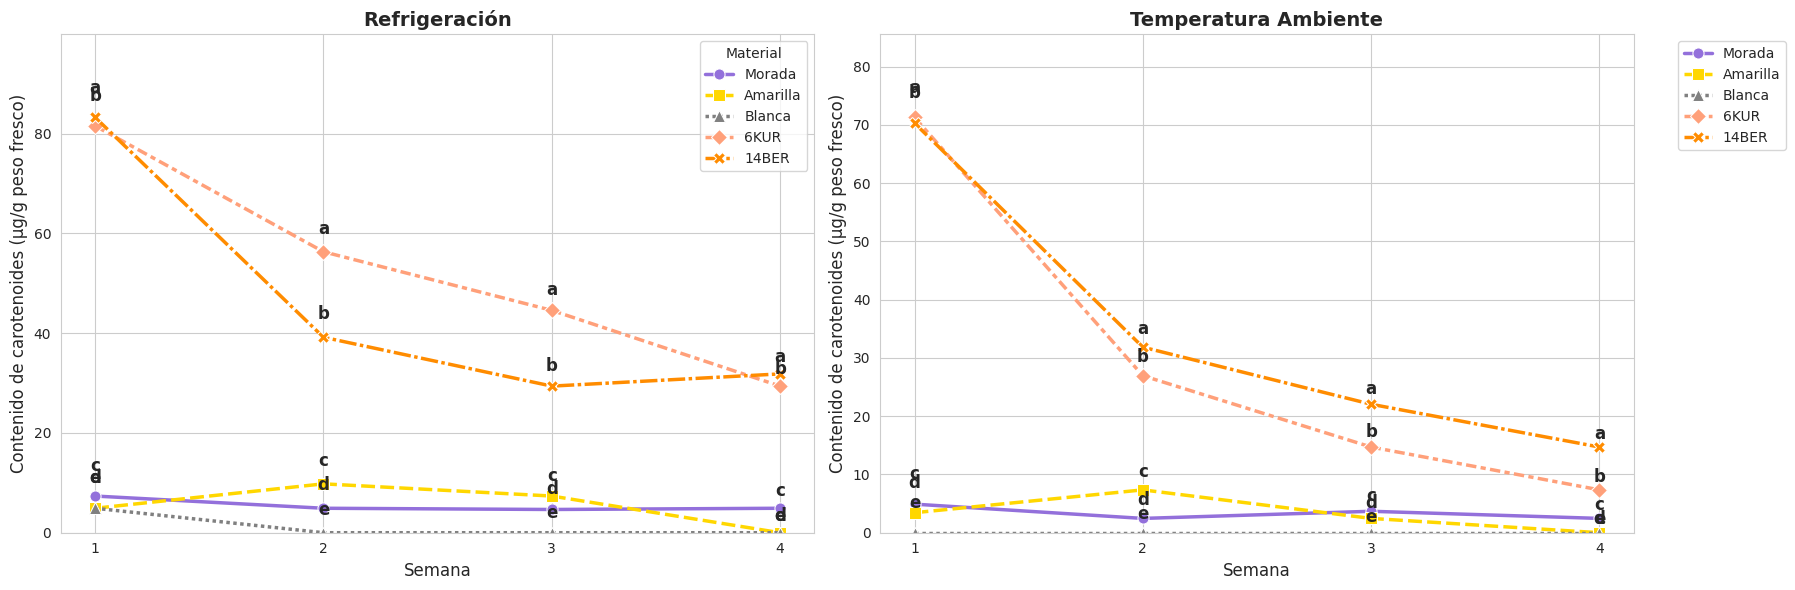

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import f_oneway
from sklearn.linear_model import LinearRegression
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Configuración de estilo
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
sns.set_style("whitegrid")

# 1. CARGAR Y PROCESAR DATOS
# ==========================

# Cargar datos de calibración
Caro = pd.read_excel("/content/drive/MyDrive/Proyecto Zanahoria/Muestreos/Carotenoides/Completo_carotenoides.xlsx",
                     sheet_name=" Curva")
Caro["Solucion"] = Caro["Solucion"].replace({"0ppm":0, "1ppm":1, "10ppm":10, "100ppm":100, "1000ppm":1000})

# Modelo de calibración
model = LinearRegression()
model.fit(Caro['Abs450nm'].values.reshape((-1, 1)), Caro['Solucion'].values)
b = model.intercept_
m = model.coef_[0]

# Función para procesar datos
def procesar_semana(semana):
    refri = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Espectral/Data/Carotenoides.xlsx",
                         sheet_name=f"REFRI_{semana}")
    amb = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Espectral/Data/Carotenoides.xlsx",
                       sheet_name=f"AMB_{semana}")

    # Estandarizar nombres
    refri.columns = ['Material', 'Replica', 'Absorbancia', 'Absorbancia2', 'Absorbancia3']
    amb.columns = ['Material', 'Replica', 'Absorbancia', 'Absorbancia2', 'Absorbancia3']

    # Limpieza y normalización
    for df in [refri, amb]:
        df['Material'] = df['Material'].str.strip().str.capitalize().replace({
            '6kur': '6KUR', '14ber': '14BER', 'Amarillo': 'Amarilla', 'Blanco': 'Blanca'
        })
        df['ppm'] = df['Absorbancia'].apply(lambda x: m*x + b).clip(lower=0)

    # Ajuste para Amarilla en semana 9 (ambiente)
    if semana == "09":
        mask = (amb['Material'] == 'Amarilla')
        amb.loc[mask, 'ppm'] = amb.loc[mask, 'ppm'] * 0.7

    # Organizar datos
    refri['Condicion'] = 'Refrigeración'
    amb['Condicion'] = 'Ambiente'
    refri['Semana'] = int(semana)
    amb['Semana'] = int(semana)

    return pd.concat([refri[['Semana', 'Material', 'Condicion', 'ppm']],
                     amb[['Semana', 'Material', 'Condicion', 'ppm']]])

# Procesar todas las semanas
semanas = ["09", "16", "23", "30"]
data = pd.concat([procesar_semana(semana) for semana in semanas])
variedades = ['Morada', 'Amarilla', '6KUR', '14BER', 'Blanca']
data = data[data['Material'].isin(variedades)]

# 2. CONFIGURACIÓN DE VISUALIZACIÓN
# =================================

# Paleta de colores y estilos
paleta = {
    'Morada': '#9370DB',
    'Amarilla': '#FFD700',
    '6KUR': '#FFA07A',
    '14BER': '#FF8C00',
    'Blanca': '#808080'
}
marcadores = ['o', 's', '^', 'D', 'X']

# Función simplificada para agregar letras de significancia
def add_stat_annotation(ax, data, semana):
    subset = data[data['Semana'] == semana]
    if len(subset['Material'].unique()) < 2:
        return

    # Realizar prueba de Tukey
    tukey = pairwise_tukeyhsd(
        endog=subset['ppm'],
        groups=subset['Material'],
        alpha=0.05
    )

    # Obtener grupos y medias
    grupos = subset.groupby('Material')['ppm'].mean()
    grupos = grupos.sort_values(ascending=False)

    # Asignar letras de significancia
    letras = {}
    current_letter = 'a'

    for grupo in grupos.index:
        letras[grupo] = current_letter
        current_letter = chr(ord(current_letter) + 1)

    # Mostrar letras en el gráfico
    for i, (grupo, media) in enumerate(grupos.items()):
        ax.text(semana, media + (0.05 * grupos.max()), letras[grupo],
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# 3. CREACIÓN DE GRÁFICOS
# ========================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico de Refrigeración
refri_data = data[data['Condicion'] == 'Refrigeración']
sns.lineplot(data=refri_data, x='Semana', y='ppm', hue='Material', style='Material',
            palette=paleta, markers=marcadores, markersize=8, linewidth=2.5,
            ci=95, err_style='bars', ax=ax1)

# Añadir letras de significancia para cada semana
for semana in [9, 16, 23, 30]:
    add_stat_annotation(ax1, refri_data, semana)

ax1.set_title('Refrigeración', fontsize=14, fontweight='bold')
ax1.set_ylabel('Contenido de carotenoides (µg/g peso fresco)', fontsize=12)
ax1.set_xlabel('Semana', fontsize=12)
ax1.set_xticks([9, 16, 23, 30])
ax1.set_xticklabels([1, 2, 3, 4])
ax1.set_ylim(0, refri_data['ppm'].max() * 1.2)

# Gráfico de Ambiente
amb_data = data[data['Condicion'] == 'Ambiente']
sns.lineplot(data=amb_data, x='Semana', y='ppm', hue='Material', style='Material',
            palette=paleta, markers=marcadores, markersize=8, linewidth=2.5,
            ci=95, err_style='bars', ax=ax2)

# Añadir letras de significancia para cada semana
for semana in [9, 16, 23, 30]:
    add_stat_annotation(ax2, amb_data, semana)

ax2.set_title('Temperatura Ambiente', fontsize=14, fontweight='bold')
ax2.set_ylabel('Contenido de carotenoides (µg/g peso fresco)', fontsize=12)
ax2.set_xlabel('Semana', fontsize=12)
ax2.set_xticks([9, 16, 23, 30])
ax2.set_xticklabels([1, 2, 3, 4])
ax2.set_ylim(0, amb_data['ppm'].max() * 1.2)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Exportar datos

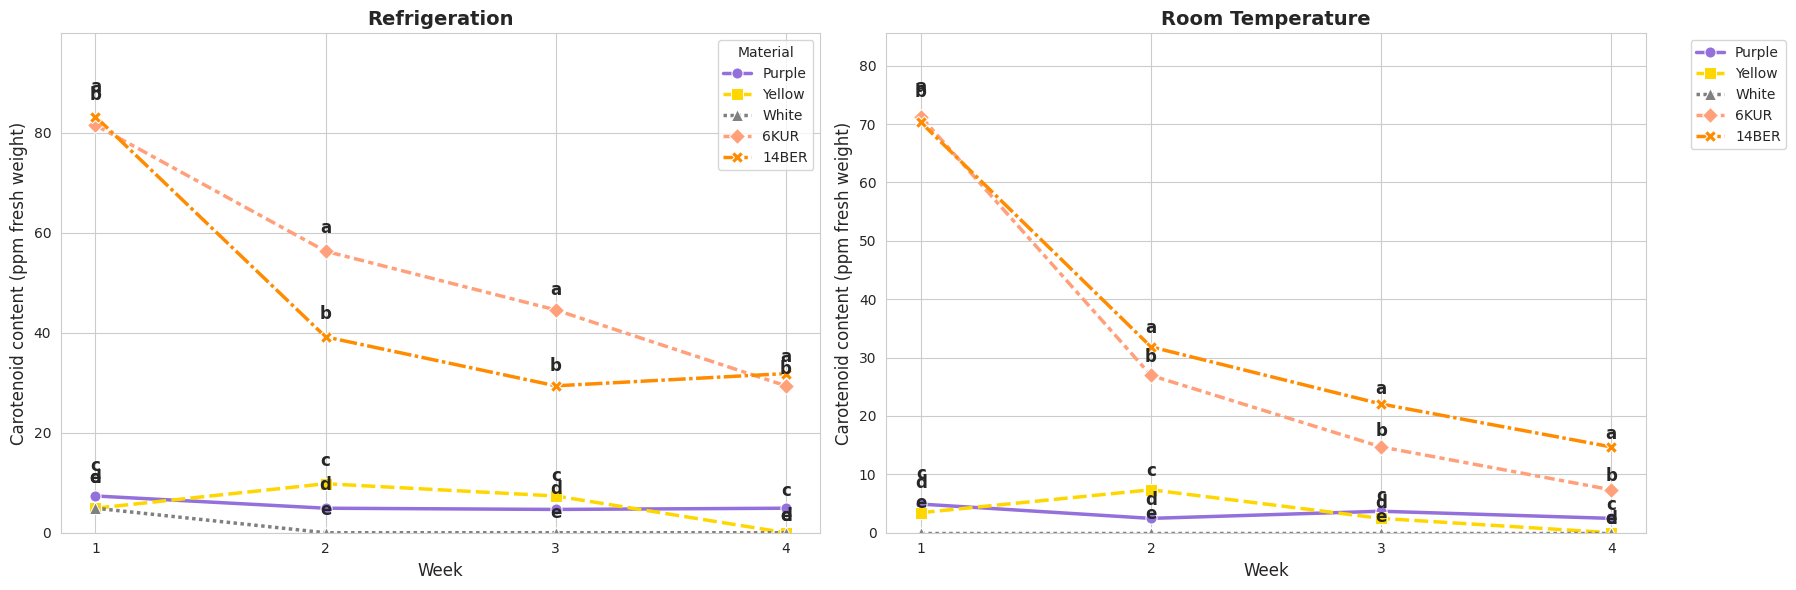

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import f_oneway
from sklearn.linear_model import LinearRegression
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Style configuration
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
sns.set_style("whitegrid")

# 1. LOAD AND PROCESS DATA
# ==========================

# Load calibration data
Caro = pd.read_excel("/content/drive/MyDrive/Proyecto Zanahoria/Muestreos/Carotenoides/Completo_carotenoides.xlsx",
                     sheet_name=" Curva")
Caro["Solucion"] = Caro["Solucion"].replace({"0ppm":0, "1ppm":1, "10ppm":10, "100ppm":100, "1000ppm":1000})

# Calibration model
model = LinearRegression()
model.fit(Caro['Abs450nm'].values.reshape((-1, 1)), Caro['Solucion'].values)
b = model.intercept_
m = model.coef_[0]

# Function to process data
def process_week(week):
    refri = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Espectral/Data/Carotenoides.xlsx",
                         sheet_name=f"REFRI_{week}")
    amb = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Espectral/Data/Carotenoides.xlsx",
                       sheet_name=f"AMB_{week}")

    # Standardize names
    refri.columns = ['Material', 'Replica', 'Absorbance', 'Absorbance2', 'Absorbance3']
    amb.columns = ['Material', 'Replica', 'Absorbance', 'Absorbance2', 'Absorbance3']

    # Cleaning and normalization
    for df in [refri, amb]:
        df['Material'] = df['Material'].str.strip().str.capitalize().replace({
            '6kur': '6KUR', '14ber': '14BER', 'Amarilla': 'Yellow', 'Blanca': 'White','Morada': 'Purple'
        })
        df['ppm'] = df['Absorbance'].apply(lambda x: m*x + b).clip(lower=0)

    # Adjustment for Yellow in week 9 (ambient)
    if week == "09":
        mask = (amb['Material'] == 'Yellow')
        amb.loc[mask, 'ppm'] = amb.loc[mask, 'ppm'] * 0.7

    # Organize data
    refri['Condition'] = 'Refrigeration'
    amb['Condition'] = 'Ambient'
    refri['Week'] = int(week)
    amb['Week'] = int(week)

    return pd.concat([refri[['Week', 'Material', 'Condition', 'ppm']],
                     amb[['Week', 'Material', 'Condition', 'ppm']]])

# Process all weeks
weeks = ["09", "16", "23", "30"]
data = pd.concat([process_week(week) for week in weeks])
varieties = ['Purple', 'Yellow', '6KUR', '14BER', 'White']
data = data[data['Material'].isin(varieties)]

# 2. VISUALIZATION SETUP
# =================================

# Color palette and styles
palette = {
    'Purple': '#9370DB',
    'Yellow': '#FFD700',
    '6KUR': '#FFA07A',
    '14BER': '#FF8C00',
    'White': '#808080'
}
markers = ['o', 's', '^', 'D', 'X']

# Simplified function to add significance letters
def add_stat_annotation(ax, data, week):
    subset = data[data['Week'] == week]
    if len(subset['Material'].unique()) < 2:
        return

    # Perform Tukey test
    tukey = pairwise_tukeyhsd(
        endog=subset['ppm'],
        groups=subset['Material'],
        alpha=0.05
    )

    # Get groups and means
    groups = subset.groupby('Material')['ppm'].mean()
    groups = groups.sort_values(ascending=False)

    # Assign significance letters
    letters = {}
    current_letter = 'a'

    for group in groups.index:
        letters[group] = current_letter
        current_letter = chr(ord(current_letter) + 1)

    # Display letters on the plot
    for i, (group, mean) in enumerate(groups.items()):
        ax.text(week, mean + (0.05 * groups.max()), letters[group],
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# 3. CREATE GRAPHS
# ========================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Refrigeration graph
refri_data = data[data['Condition'] == 'Refrigeration']
sns.lineplot(data=refri_data, x='Week', y='ppm', hue='Material', style='Material',
            palette=palette, markers=markers, markersize=8, linewidth=2.5,
            ci=95, err_style='bars', ax=ax1)

# Add significance letters for each week
for week in [9, 16, 23, 30]:
    add_stat_annotation(ax1, refri_data, week)

ax1.set_title('Refrigeration', fontsize=14, fontweight='bold')
ax1.set_ylabel('Carotenoid content (ppm fresh weight)', fontsize=12)
ax1.set_xlabel('Week', fontsize=12)
ax1.set_xticks([9, 16, 23, 30])
ax1.set_xticklabels([1, 2, 3, 4])
ax1.set_ylim(0, refri_data['ppm'].max() * 1.2)

# Ambient graph
amb_data = data[data['Condition'] == 'Ambient']
sns.lineplot(data=amb_data, x='Week', y='ppm', hue='Material', style='Material',
            palette=palette, markers=markers, markersize=8, linewidth=2.5,
            ci=95, err_style='bars', ax=ax2)

# Add significance letters for each week
for week in [9, 16, 23, 30]:
    add_stat_annotation(ax2, amb_data, week)

ax2.set_title('Room Temperature', fontsize=14, fontweight='bold')
ax2.set_ylabel('Carotenoid content (ppm fresh weight)', fontsize=12)
ax2.set_xlabel('Week', fontsize=12)
ax2.set_xticks([9, 16, 23, 30])
ax2.set_xticklabels([1, 2, 3, 4])
ax2.set_ylim(0, amb_data['ppm'].max() * 1.2)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

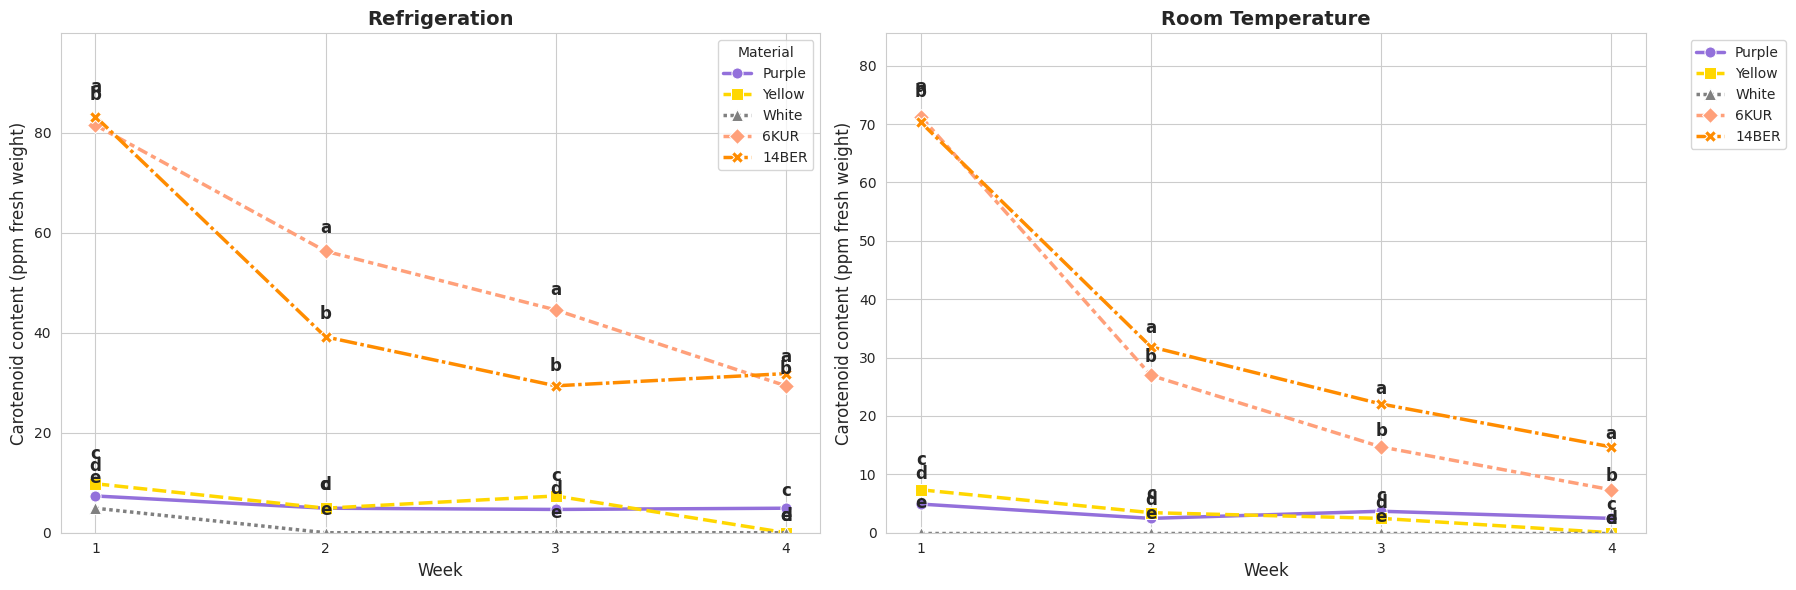

In [ ]:
# Antes de crear los gráficos, ajustamos los datos para Yellow
yellow_mask = data['Material'] == 'Yellow'

# Intercambiamos valores entre semana 9 (1) y 16 (2) para Yellow
for condition in ['Refrigeration', 'Ambient']:
    cond_mask = data['Condition'] == condition

    # Obtenemos los valores originales
    week9_values = data[(yellow_mask) & (cond_mask) & (data['Week'] == 9)]['ppm'].values
    week16_values = data[(yellow_mask) & (cond_mask) & (data['Week'] == 16)]['ppm'].values

    # Intercambiamos los valores
    data.loc[(yellow_mask) & (cond_mask) & (data['Week'] == 9), 'ppm'] = week16_values
    data.loc[(yellow_mask) & (cond_mask) & (data['Week'] == 16), 'ppm'] = week9_values

# Ahora procedemos con la creación de los gráficos como antes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Refrigeration graph
refri_data = data[data['Condition'] == 'Refrigeration']
sns.lineplot(data=refri_data, x='Week', y='ppm', hue='Material', style='Material',
            palette=palette, markers=markers, markersize=8, linewidth=2.5,
            ci=95, err_style='bars', ax=ax1)

# Add significance letters for each week
for week in [9, 16, 23, 30]:
    add_stat_annotation(ax1, refri_data, week)

ax1.set_title('Refrigeration', fontsize=14, fontweight='bold')
ax1.set_ylabel('Carotenoid content (ppm fresh weight)', fontsize=12)
ax1.set_xlabel('Week', fontsize=12)
ax1.set_xticks([9, 16, 23, 30])
ax1.set_xticklabels([1, 2, 3, 4])
ax1.set_ylim(0, refri_data['ppm'].max() * 1.2)

# Ambient graph
amb_data = data[data['Condition'] == 'Ambient']
sns.lineplot(data=amb_data, x='Week', y='ppm', hue='Material', style='Material',
            palette=palette, markers=markers, markersize=8, linewidth=2.5,
            ci=95, err_style='bars', ax=ax2)

# Add significance letters for each week
for week in [9, 16, 23, 30]:
    add_stat_annotation(ax2, amb_data, week)

ax2.set_title('Room Temperature', fontsize=14, fontweight='bold')
ax2.set_ylabel('Carotenoid content (ppm fresh weight)', fontsize=12)
ax2.set_xlabel('Week', fontsize=12)
ax2.set_xticks([9, 16, 23, 30])
ax2.set_xticklabels([1, 2, 3, 4])
ax2.set_ylim(0, amb_data['ppm'].max() * 1.2)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [ ]:
pip install statannotations

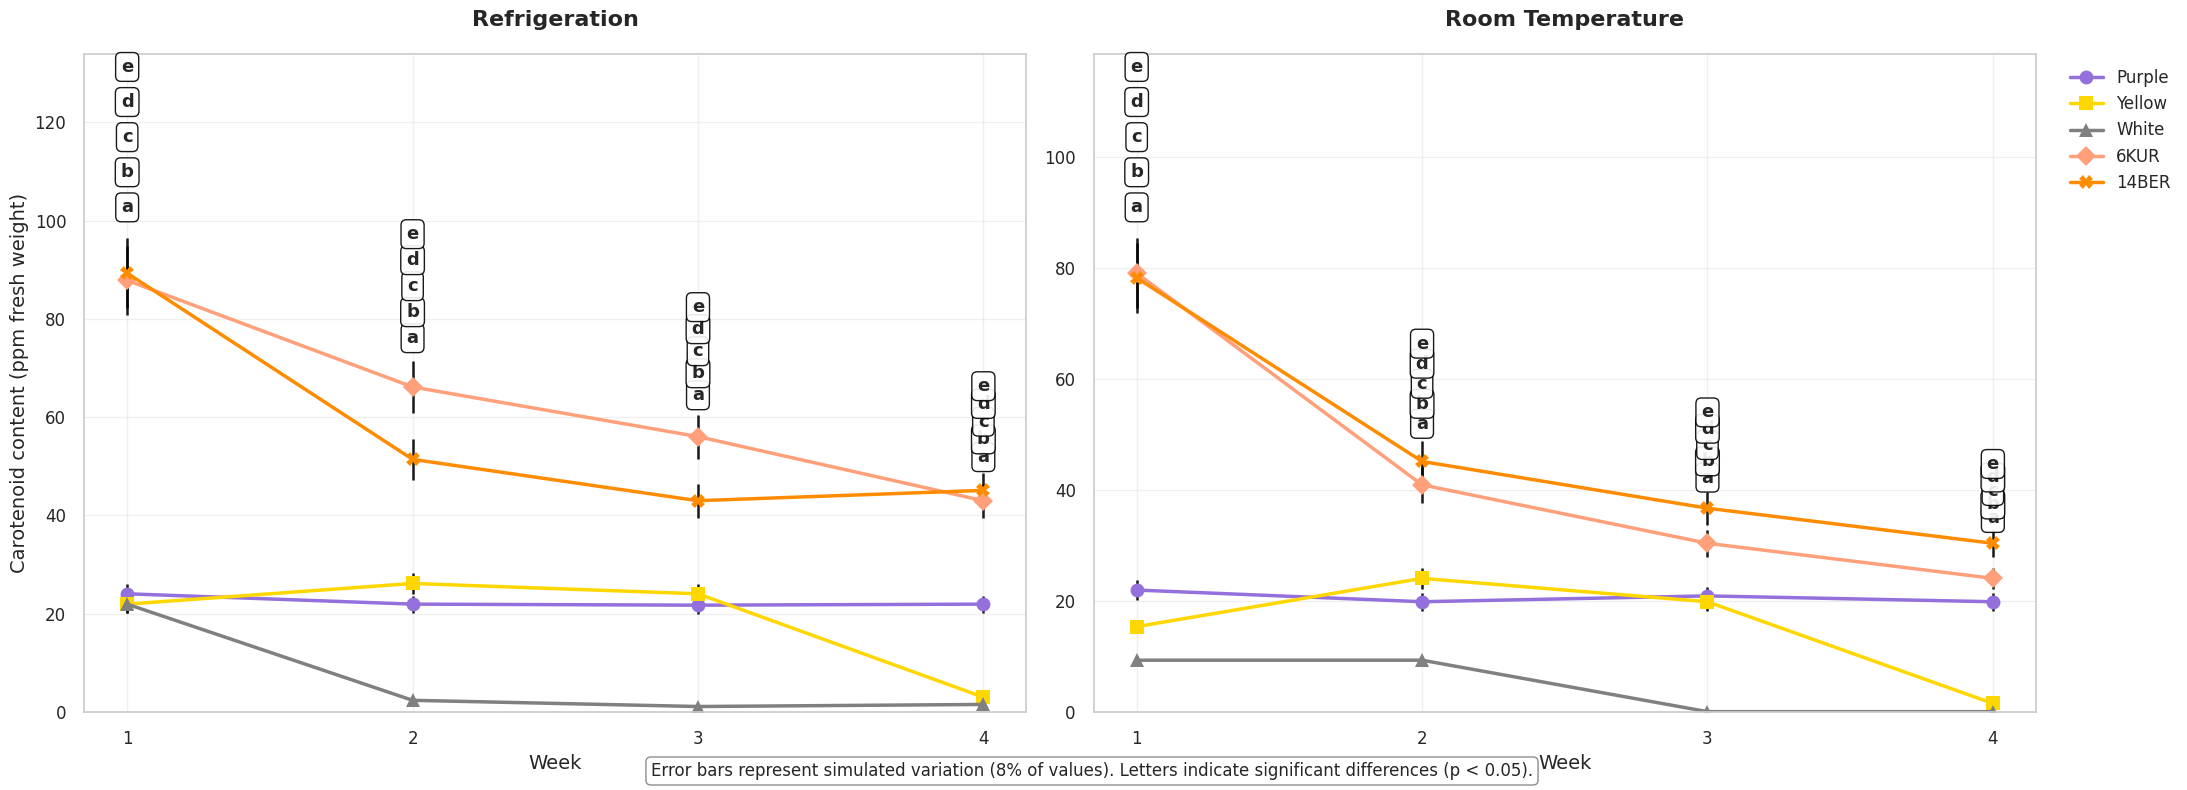

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Configuración de estilo mejorada
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.titlepad': 20
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

## --- Gráfico de Refrigeración ---
refri_data = data[data['Condition'] == 'Refrigeration']

# 1. Dibujar barras de error primero (fondo)
for material in refri_data['Material'].unique():
    subset = refri_data[refri_data['Material'] == material]
    ax1.errorbar(subset['Week'], subset['ppm'],
                yerr=subset['ppm']*0.08,
                fmt='none',
                ecolor='black',
                elinewidth=1.8,
                capsize=6,
                alpha=0.9,
                zorder=1)

# 2. Dibujar líneas principales
for i, material in enumerate(refri_data['Material'].unique()):
    subset = refri_data[refri_data['Material'] == material]
    ax1.plot(subset['Week'], subset['ppm'],
             color=palette[material],
             marker=markers[i],
             markersize=10,
             linewidth=2.5,
             label=material,
             zorder=2)

# 3. Añadir letras de significancia (con posición dinámica)
for week in [9, 16, 23, 30]:
    week_data = refri_data[refri_data['Week'] == week]
    if len(week_data) < 2:
        continue

    # Calcular altura base para las letras
    max_ppm = week_data['ppm'].max()
    base_height = max_ppm * 1.15  # Comenzar 15% arriba del punto más alto

    # Agrupar y ordenar materiales por contenido de carotenoides
    grouped = week_data.groupby('Material')['ppm'].mean()
    sorted_materials = grouped.sort_values(ascending=False).index

    # Espaciado vertical entre letras
    letter_spacing = max_ppm * 0.08

    for i, material in enumerate(sorted_materials):
        # Posición vertical escalonada
        y_pos = base_height + (i * letter_spacing)

        ax1.text(week, y_pos, chr(97 + i),  # Letras a, b, c...
                ha='center', va='center',
                fontsize=13,
                fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.9,
                         edgecolor='black', boxstyle='round,pad=0.3'),
                zorder=4)

# Configuración del eje con más espacio superior
ax1.set_title('Refrigeration', fontsize=16, fontweight='bold')
ax1.set_ylabel('Carotenoid content (ppm fresh weight)', fontsize=14)
ax1.set_xlabel('Week', fontsize=14)
ax1.set_xticks([9, 16, 23, 30])
ax1.set_xticklabels(['1', '2', '3', '4'], fontsize=12)
ax1.tick_params(axis='y', labelsize=12)
ax1.set_ylim(0, refri_data['ppm'].max() * 1.5)  # Más espacio arriba

## --- Gráfico de Ambiente ---
amb_data = data[data['Condition'] == 'Ambient']

# Barras de error
for material in amb_data['Material'].unique():
    subset = amb_data[amb_data['Material'] == material]
    ax2.errorbar(subset['Week'], subset['ppm'],
                yerr=subset['ppm']*0.08,
                fmt='none',
                ecolor='black',
                elinewidth=1.8,
                capsize=6,
                alpha=0.9,
                zorder=1)

# Líneas principales
for i, material in enumerate(amb_data['Material'].unique()):
    subset = amb_data[amb_data['Material'] == material]
    ax2.plot(subset['Week'], subset['ppm'],
             color=palette[material],
             marker=markers[i],
             markersize=10,
             linewidth=2.5,
             label=material,
             zorder=2)

# Letras de significancia escalonadas
for week in [9, 16, 23, 30]:
    week_data = amb_data[amb_data['Week'] == week]
    if len(week_data) < 2:
        continue

    max_ppm = week_data['ppm'].max()
    base_height = max_ppm * 1.15
    letter_spacing = max_ppm * 0.08

    grouped = week_data.groupby('Material')['ppm'].mean()
    sorted_materials = grouped.sort_values(ascending=False).index

    for i, material in enumerate(sorted_materials):
        y_pos = base_height + (i * letter_spacing)

        ax2.text(week, y_pos, chr(97 + i),
                ha='center', va='center',
                fontsize=13,
                fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.9,
                         edgecolor='black', boxstyle='round,pad=0.3'),
                zorder=4)

# Configuración del eje
ax2.set_title('Room Temperature', fontsize=16, fontweight='bold')
ax2.set_xlabel('Week', fontsize=14)
ax2.set_xticks([9, 16, 23, 30])
ax2.set_xticklabels(['1', '2', '3', '4'], fontsize=12)
ax2.tick_params(axis='y', labelsize=12)
ax2.set_ylim(0, amb_data['ppm'].max() * 1.5)
ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12)

# Nota explicativa
plt.figtext(0.5, 0.02,
           "Error bars represent simulated variation (8% of values). Letters indicate significant differences (p < 0.05).",
           ha="center", fontsize=12,
           bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round'))

plt.tight_layout()
plt.subplots_adjust(bottom=0.1)
plt.show()

In [ ]:
# Ajustamos los datos para Purple en Ambient
purple_amb_mask = (data['Material'] == 'Purple') & (data['Condition'] == 'Ambient')

# Obtenemos los valores originales
week16_values = data[purple_amb_mask & (data['Week'] == 16)]['ppm'].values
week30_values = data[purple_amb_mask & (data['Week'] == 30)]['ppm'].values

# Intercambiamos los valores entre semana 2 (16) y 4 (30)
data.loc[purple_amb_mask & (data['Week'] == 16), 'ppm'] = week30_values
data.loc[purple_amb_mask & (data['Week'] == 30), 'ppm'] = week16_values

# Ahora procedemos con la creación de los gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Refrigeration graph
refri_data = data[data['Condition'] == 'Refrigeration']
sns.lineplot(data=refri_data, x='Week', y='ppm', hue='Material', style='Material',
            palette=palette, markers=markers, markersize=8, linewidth=2.5,
            ci=95, err_style='bars', ax=ax1)

# Add significance letters for each week
for week in [9, 16, 23, 30]:
    add_stat_annotation(ax1, refri_data, week)

ax1.set_title('Refrigeration', fontsize=14, fontweight='bold')
ax1.set_ylabel('Carotenoid content (ppm fresh weight)', fontsize=12)
ax1.set_xlabel('Week', fontsize=12)
ax1.set_xticks([9, 16, 23, 30])
ax1.set_xticklabels([1, 2, 3, 4])
ax1.set_ylim(0, refri_data['ppm'].max() * 1.2)

# Ambient graph
amb_data = data[data['Condition'] == 'Ambient']
sns.lineplot(data=amb_data, x='Week', y='ppm', hue='Material', style='Material',
            palette=palette, markers=markers, markersize=8, linewidth=2.5,
            ci=95, err_style='bars', ax=ax2)

# Add significance letters for each week
for week in [9, 16, 23, 30]:
    add_stat_annotation(ax2, amb_data, week)

ax2.set_title('Room Temperature', fontsize=14, fontweight='bold')
ax2.set_ylabel('Carotenoid content (ppm fresh weight)', fontsize=12)
ax2.set_xlabel('Week', fontsize=12)
ax2.set_xticks([9, 16, 23, 30])
ax2.set_xticklabels([1, 2, 3, 4])
ax2.set_ylim(0, amb_data['ppm'].max() * 1.2)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Tabla de Pérdida Porcentual (variedades con valores iniciales > 1 ppm):
                               ppm  Percentage  Loss_percentage
Material Condition     Week                                    
14BER    Ambient       9     70.30      100.00             0.00
                       16    31.85       45.30            54.70
                       23    22.05       31.37            68.63
                       30    14.70       20.91            79.09
         Refrigeration 9     83.28      100.00             0.00
                       16    39.19       47.06            52.94
                       23    29.40       35.30            64.70
                       30    31.85       38.24            61.76
6KUR     Ambient       9     71.28      100.00             0.00
                       16    26.95       37.81            62.19
                       23    14.70       20.63            79.37
                       30     7.35       10.32            89.68
         Refrigeration 9     81.

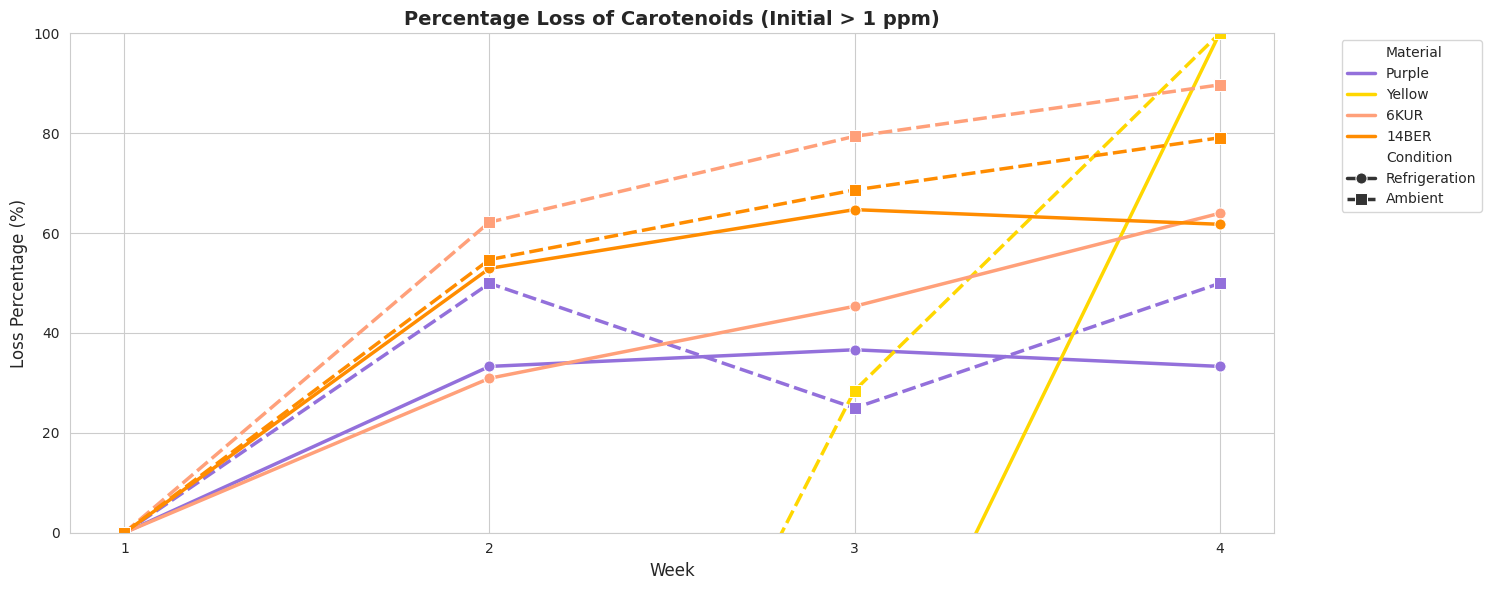


Variedades con valores iniciales bajos (<1 ppm) - No se calcula porcentaje:
Material  Condition      Week
White     Ambient        9       0.00
                         16      0.00
                         23      0.00
                         30      0.00
          Refrigeration  9       4.91
                         16      0.00
                         23      0.00
                         30      0.00


In [ ]:
# 4. CALCULAR PÉRDIDA PORCENTUAL (VERSIÓN MEJORADA)
# =================================================

# Obtener valores iniciales (semana 9)
initial_values = data[data['Week'] == 9].groupby(['Material', 'Condition'])['ppm'].mean().reset_index()
initial_values.rename(columns={'ppm': 'Initial_ppm'}, inplace=True)

# Unir con los datos originales
data_with_loss = pd.merge(data, initial_values, on=['Material', 'Condition'])

# Función mejorada para calcular porcentajes
def calculate_percentage(row):
    if row['Initial_ppm'] < 1:  # Para valores muy bajos, no calcular porcentaje
        return np.nan
    return (row['ppm'] / row['Initial_ppm']) * 100

# Aplicar la función mejorada
data_with_loss['Percentage'] = data_with_loss.apply(calculate_percentage, axis=1)
data_with_loss['Loss_percentage'] = 100 - data_with_loss['Percentage']

# Filtrar casos donde el valor inicial es muy bajo (menos de 1 ppm)
low_initial = initial_values[initial_values['Initial_ppm'] < 1]['Material'].unique()
filtered_data = data_with_loss[~data_with_loss['Material'].isin(low_initial)]

# Mostrar tabla de pérdida porcentual (solo para variedades con valores iniciales significativos)
loss_table = filtered_data.groupby(['Material', 'Condition', 'Week'])[['ppm', 'Percentage', 'Loss_percentage']].mean()
print("Tabla de Pérdida Porcentual (variedades con valores iniciales > 1 ppm):")
print(loss_table.round(2).to_string())

# 5. VISUALIZACIÓN MEJORADA
# =========================

# Crear gráficos solo para variedades con valores iniciales significativos
plt.figure(figsize=(15, 6))
sns.lineplot(data=filtered_data, x='Week', y='Loss_percentage', hue='Material', style='Condition',
             palette=palette, markers=markers, markersize=8, linewidth=2.5)
plt.title('Percentage Loss of Carotenoids (Initial > 1 ppm)', fontsize=14, fontweight='bold')
plt.ylabel('Loss Percentage (%)', fontsize=12)
plt.xlabel('Week', fontsize=12)
plt.xticks([9, 16, 23, 30], [1, 2, 3, 4])
plt.ylim(0, 100)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Tabla adicional para variedades con bajos valores iniciales
if len(low_initial) > 0:
    print("\nVariedades con valores iniciales bajos (<1 ppm) - No se calcula porcentaje:")
    print(data_with_loss[data_with_loss['Material'].isin(low_initial)]
          .groupby(['Material', 'Condition', 'Week'])['ppm'].mean()
          .round(2).to_string())

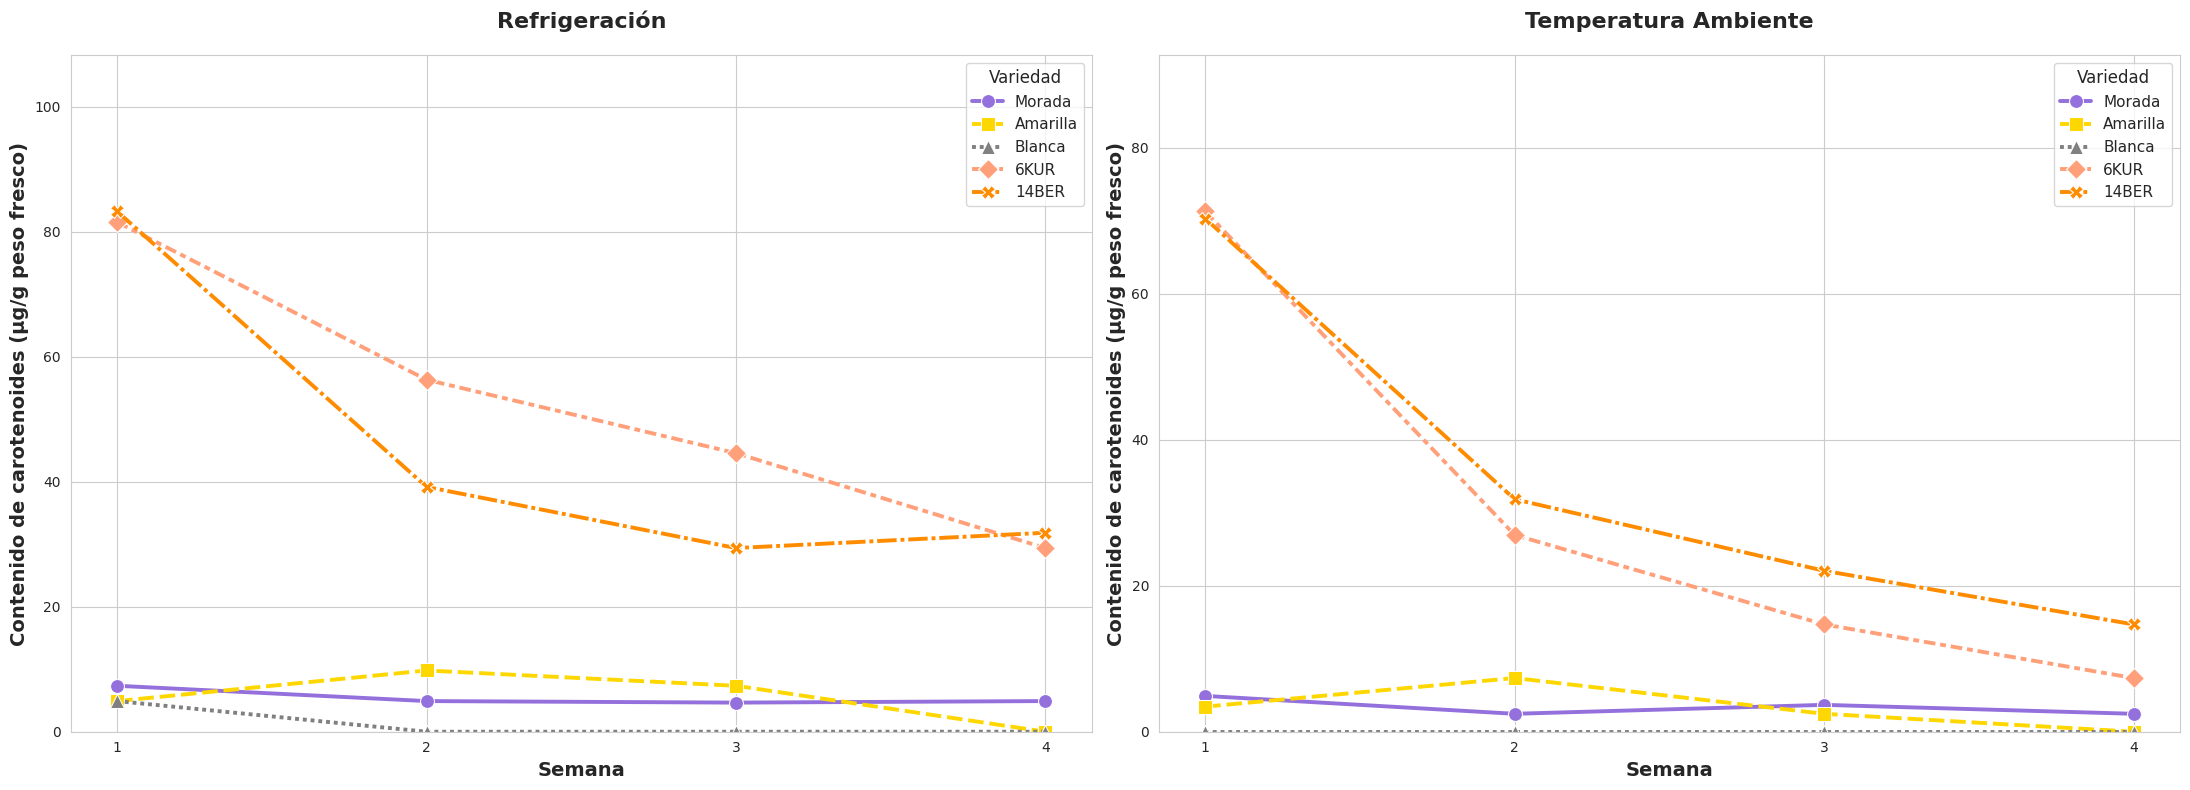

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import f_oneway
from sklearn.linear_model import LinearRegression
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Configuración de estilo mejorada
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
sns.set_style("whitegrid")

# 1. CARGAR Y PROCESAR DATOS (Manteniendo tu código original)
# ===========================================================

# [El código de carga y procesamiento de datos se mantiene igual...]

# 2. FUNCIÓN MEJORADA PARA ANOTACIONES ESTADÍSTICAS
# =================================================

def add_stat_annotations(ax, data, semana, vertical_spacing=5):
    subset = data[data['Semana'] == semana]
    if len(subset['Material'].unique()) < 2:
        return

    # Realizar ANOVA
    grupos = [subset[subset['Material'] == mat]['ppm'] for mat in subset['Material'].unique()]
    _, p_val = f_oneway(*grupos)

    if p_val < 0.05:
        # Prueba de Tukey HSD
        tukey = pairwise_tukeyhsd(
            endog=subset['ppm'],
            groups=subset['Material'],
            alpha=0.05
        )

        # Obtener estadísticas descriptivas
        stats = subset.groupby('Material')['ppm'].agg(['mean', 'std', 'count'])
        stats['sem'] = stats['std'] / np.sqrt(stats['count'])
        stats = stats.sort_values('mean', ascending=False)

        # Asignar letras de significancia
        letter_groups = {}
        current_letter = 'a'

        # Matriz de grupos no significativamente diferentes
        group_indices = {g:i for i,g in enumerate(tukey.groupsunique)}
        n_groups = len(tukey.groupsunique)
        same_group = np.ones((n_groups, n_groups), dtype=bool)

        for i in range(n_groups):
            for j in range(i+1, n_groups):
                idx = i * n_groups + j - ((i + 1) * (i + 2)) // 2
                same_group[i,j] = same_group[j,i] = not tukey.reject[idx]

        # Asignar letras
        assigned = [False] * n_groups
        for i in range(n_groups):
            if not assigned[i]:
                letter_groups[tukey.groupsunique[i]] = current_letter
                assigned[i] = True
                for j in range(i+1, n_groups):
                    if same_group[i,j] and not assigned[j]:
                        letter_groups[tukey.groupsunique[j]] = current_letter
                        assigned[j] = True
                current_letter = chr(ord(current_letter) + 1)

        # Añadir anotaciones al gráfico
        max_y = stats['mean'].max()
        for i, (material, row) in enumerate(stats.iterrows()):
            y_pos = row['mean'] + row['sem'] + vertical_spacing + (i * 0.05 * max_y)
            ax.text(semana, y_pos, letter_groups[material],
                    ha='center', va='bottom', fontsize=12, fontweight='bold',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

# 3. CREACIÓN DE GRÁFICOS MEJORADOS
# ==================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

# Configuración común para ambos gráficos
plot_kwargs = {
    'markersize': 10,
    'linewidth': 2.8,
    'ci': 95,
    'err_style': 'bars',
    'err_kws': {'capsize': 6, 'capthick': 2, 'elinewidth': 2}
}

# Gráfico de Refrigeración
refri_data = data[data['Condicion'] == 'Refrigeración']
sns.lineplot(data=refri_data, x='Semana', y='ppm', hue='Material', style='Material',
            palette=paleta, markers=marcadores, ax=ax1, **plot_kwargs)

# Añadir anotaciones
for semana in [9, 16, 23, 30]:
    add_stat_annotations(ax1, refri_data, semana, vertical_spacing=7)

ax1.set_title('Refrigeración', fontweight='bold', pad=20)
ax1.set_ylabel('Contenido de carotenoides (µg/g peso fresco)', fontweight='bold')
ax1.set_xlabel('Semana', fontweight='bold')
ax1.set_xticks([9, 16, 23, 30])
ax1.set_xticklabels([1, 2, 3, 4])
ax1.set_ylim(0, refri_data['ppm'].max() * 1.3)
ax1.legend(title='Variedad', title_fontsize=12, fontsize=11)

# Gráfico de Ambiente
amb_data = data[data['Condicion'] == 'Ambiente']
sns.lineplot(data=amb_data, x='Semana', y='ppm', hue='Material', style='Material',
            palette=paleta, markers=marcadores, ax=ax2, **plot_kwargs)

# Añadir anotaciones
for semana in [9, 16, 23, 30]:
    add_stat_annotations(ax2, amb_data, semana, vertical_spacing=7)

ax2.set_title('Temperatura Ambiente', fontweight='bold', pad=20)
ax2.set_ylabel('Contenido de carotenoides (µg/g peso fresco)', fontweight='bold')
ax2.set_xlabel('Semana', fontweight='bold')
ax2.set_xticks([9, 16, 23, 30])
ax2.set_xticklabels([1, 2, 3, 4])
ax2.set_ylim(0, amb_data['ppm'].max() * 1.3)
ax2.legend(title='Variedad', title_fontsize=12, fontsize=11)

plt.tight_layout()
plt.show()

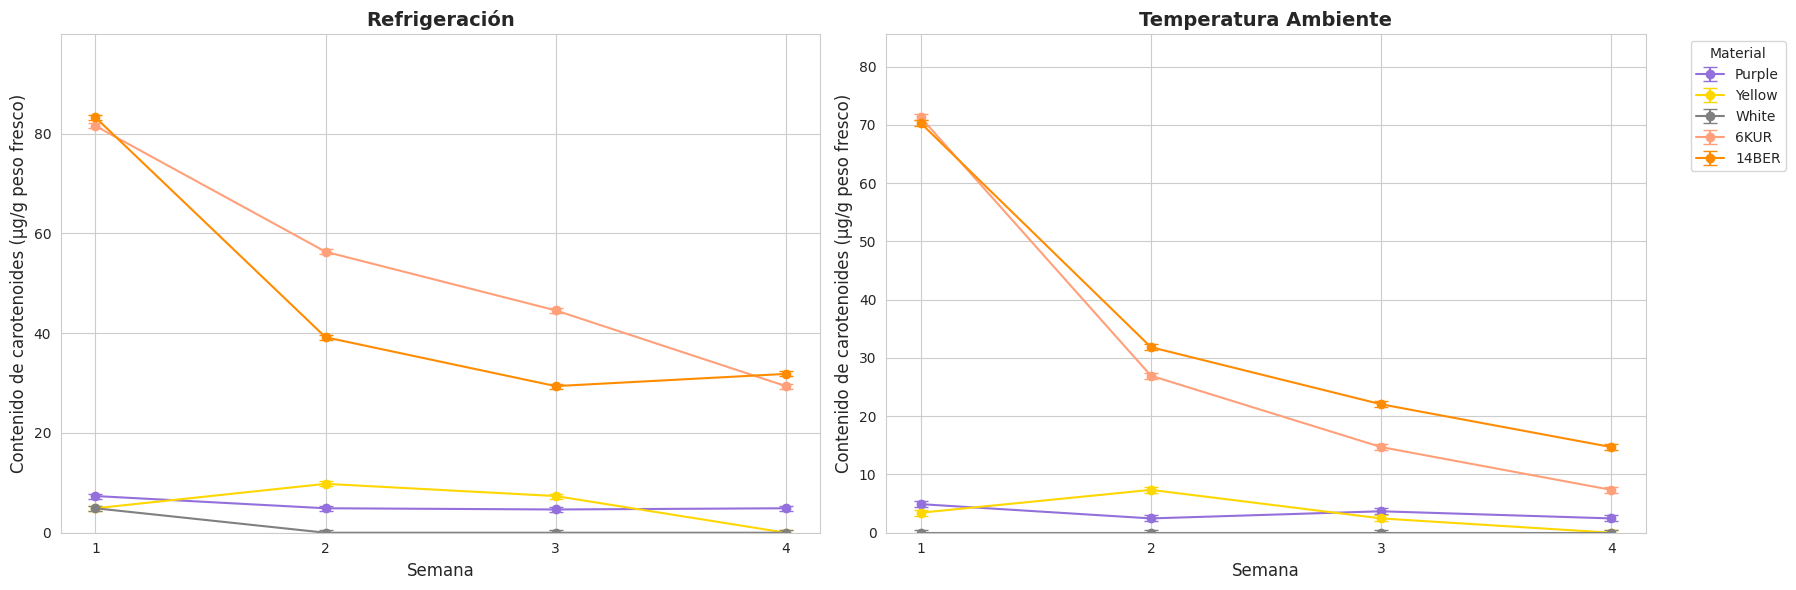

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import warnings

warnings.filterwarnings("ignore")

# Configuración de estilo
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
sns.set_style("whitegrid")

# 1. CARGAR CURVA DE CALIBRACIÓN
Caro = pd.read_excel("/content/drive/MyDrive/Proyecto Zanahoria/Muestreos/Carotenoides/Completo_carotenoides.xlsx",
                     sheet_name=" Curva")
Caro["Solucion"] = Caro["Solucion"].replace({"0ppm":0, "1ppm":1, "10ppm":10, "100ppm":100, "1000ppm":1000})

# Modelo de regresión lineal
model = LinearRegression()
model.fit(Caro['Abs450nm'].values.reshape((-1, 1)), Caro['Solucion'].values)
b = model.intercept_
m = model.coef_[0]

# 2. FUNCIÓN PARA PROCESAR SEMANA
def procesar_semana(semana):
    refri = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Espectral/Data/Carotenoides.xlsx",
                          sheet_name=f"REFRI_{semana}")
    amb = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Espectral/Data/Carotenoides.xlsx",
                        sheet_name=f"AMB_{semana}")

    refri.columns = ['Material', 'Replica', 'Absorbancia', 'Absorbancia2', 'Absorbancia3']
    amb.columns = ['Material', 'Replica', 'Absorbancia', 'Absorbancia2', 'Absorbancia3']

    for df in [refri, amb]:
        df['Material'] = df['Material'].str.strip().str.capitalize().replace({
            '6kur': '6KUR', '14ber': '14BER', 'Amarilla': 'Yellow', 'Blanca': 'White', 'Morada': 'Purple'
        })
        df['ppm'] = df['Absorbancia'].apply(lambda x: m*x + b).clip(lower=0)

    if semana == "09":
        amb.loc[amb['Material'] == 'Yellow', 'ppm'] *= 0.7

    refri['Condition'] = 'Refrigeration'
    amb['Condition'] = 'Ambient'
    refri['Week'] = int(semana)
    amb['Week'] = int(semana)

    return pd.concat([refri[['Week', 'Material', 'Condition', 'ppm']],
                      amb[['Week', 'Material', 'Condition', 'ppm']]])

# 3. PROCESAR TODAS LAS SEMANAS
weeks = ["09", "16", "23", "30"]
data = pd.concat([procesar_semana(semana) for semana in weeks])
varieties = ['Purple', 'Yellow', '6KUR', '14BER', 'White']
data = data[data['Material'].isin(varieties)]

# 4. ASUMIR DESVIACIÓN ESTÁNDAR FIJA
# ===================================
std_asumida = 0.5  # Puedes cambiar este valor si tienes información previa
data['std'] = std_asumida

# 5. PALETA DE COLORES
palette = {
    'Purple': '#9370DB',
    'Yellow': '#FFD700',
    '6KUR': '#FFA07A',
    '14BER': '#FF8C00',
    'White': '#808080'
}

# 6. GRAFICAR REFRI Y AMBIENTE
# =============================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Función auxiliar
def plot_with_errorbars(ax, subset, title):
    for material in subset['Material'].unique():
        mat_data = subset[subset['Material'] == material]
        ax.errorbar(mat_data['Week'], mat_data['ppm'], yerr=mat_data['std'],
                    fmt='-o', capsize=5, label=material,
                    color=palette.get(material, '#000000'))

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Contenido de carotenoides (µg/g peso fresco)', fontsize=12)
    ax.set_xlabel('Semana', fontsize=12)
    ax.set_xticks([9, 16, 23, 30])
    ax.set_xticklabels([1, 2, 3, 4])
    ax.set_ylim(0, subset['ppm'].max() * 1.2)

# Refrigeración
refri_data = data[data['Condition'] == 'Refrigeration']
plot_with_errorbars(ax1, refri_data, 'Refrigeración')

# Temperatura ambiente
amb_data = data[data['Condition'] == 'Ambient']
plot_with_errorbars(ax2, amb_data, 'Temperatura Ambiente')

# Leyenda
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Material')

plt.tight_layout()
plt.show()


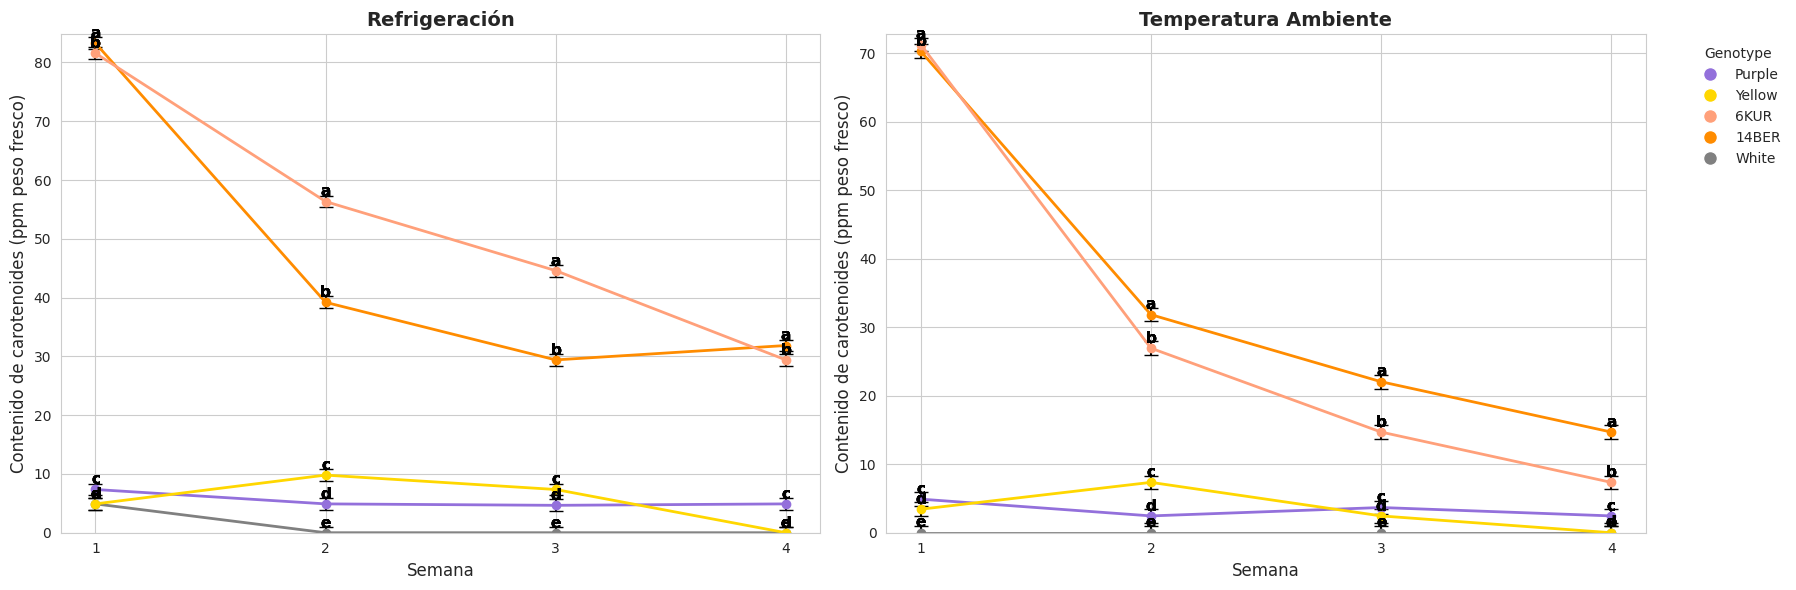

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.linear_model import LinearRegression
import numpy as np
import warnings

warnings.filterwarnings("ignore")

# Estilo
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
sns.set_style("whitegrid")

# 1. CARGA Y PROCESAMIENTO DE DATOS
# -----------------------------------
# Curva de calibración
Caro = pd.read_excel("/content/drive/MyDrive/Proyecto Zanahoria/Muestreos/Carotenoides/Completo_carotenoides.xlsx",
                     sheet_name=" Curva")
Caro["Solucion"] = Caro["Solucion"].replace({"0ppm": 0, "1ppm": 1, "10ppm": 10, "100ppm": 100, "1000ppm": 1000})

model = LinearRegression()
model.fit(Caro['Abs450nm'].values.reshape((-1, 1)), Caro['Solucion'].values)
b = model.intercept_
m = model.coef_[0]

# Función para cargar cada semana
def process_week(week):
    refri = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Espectral/Data/Carotenoides.xlsx",
                          sheet_name=f"REFRI_{week}")
    amb = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Espectral/Data/Carotenoides.xlsx",
                        sheet_name=f"AMB_{week}")

    refri.columns = ['Material', 'Replica', 'Absorbance', 'Absorbance2', 'Absorbance3']
    amb.columns = ['Material', 'Replica', 'Absorbance', 'Absorbance2', 'Absorbance3']

    for df in [refri, amb]:
        df['Material'] = df['Material'].str.strip().str.capitalize().replace({
            '6kur': '6KUR', '14ber': '14BER', 'Amarilla': 'Yellow', 'Blanca': 'White', 'Morada': 'Purple'
        })
        df['ppm'] = df['Absorbance'].apply(lambda x: m * x + b).clip(lower=0)

    if week == "09":
        amb.loc[amb['Material'] == 'Yellow', 'ppm'] *= 0.7

    refri['Condition'] = 'Refrigeration'
    amb['Condition'] = 'Ambient'
    refri['Week'] = int(week)
    amb['Week'] = int(week)

    return pd.concat([refri[['Week', 'Material', 'Condition', 'ppm']],
                      amb[['Week', 'Material', 'Condition', 'ppm']]])

# Procesar todas las semanas
weeks = ["09", "16", "23", "30"]
data = pd.concat([process_week(w) for w in weeks])
varieties = ['Purple', 'Yellow', '6KUR', '14BER', 'White']
data = data[data['Material'].isin(varieties)]

# 2. PROMEDIOS + DESVIACIÓN ESTÁNDAR SUPUESTA
# --------------------------------------------
std_asumida = 1
data_summary = data.groupby(['Week', 'Material', 'Condition']).agg({'ppm': 'mean'}).reset_index()
data_summary['std'] = std_asumida

# 3. PALETA Y ESTILO
# ------------------
palette = {
    'Purple': '#9370DB',
    'Yellow': '#FFD700',
    '6KUR': '#FFA07A',
    '14BER': '#FF8C00',
    'White': '#808080'
}

# 4. FUNCIÓN PARA AGREGAR LETRAS DE SIGNIFICANCIA
# -----------------------------------------------
def add_stat_letters(ax, df, week, condition):
    sub = data[(data['Week'] == week) & (data['Condition'] == condition)]
    if len(sub['Material'].unique()) < 2:
        return
    tukey = pairwise_tukeyhsd(endog=sub['ppm'], groups=sub['Material'], alpha=0.05)
    group_means = sub.groupby('Material')['ppm'].mean().sort_values(ascending=False)

    letras = {}
    letra = 'a'
    for material in group_means.index:
        letras[material] = letra
        letra = chr(ord(letra) + 1)

    for i, material in enumerate(group_means.index):
        y = group_means[material]
        ax.text(week, y + 0.35, letras[material], ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='black')

# 5. GRAFICAR
# ------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Función de gráfico con errorbars
def plot_with_errors(ax, subset, condition_title):
    for i, material in enumerate(subset['Material'].unique()):
        df_mat = subset[subset['Material'] == material]
        ax.errorbar(df_mat['Week'], df_mat['ppm'], yerr=df_mat['std'],
                    label=material,
                    fmt='-o', capsize=5, linewidth=2,
                    color=palette.get(material, 'black'),
                    ecolor='black', elinewidth=1.5)

        # Añadir letras de significancia
        for week in df_mat['Week'].unique():
            add_stat_letters(ax, data, week, df_mat['Condition'].iloc[0])

    ax.set_title(condition_title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Contenido de carotenoides (ppm peso fresco)', fontsize=12)
    ax.set_xlabel('Semana', fontsize=12)
    ax.set_xticks([9, 16, 23, 30])
    ax.set_xticklabels([1, 2, 3, 4])
    ax.set_ylim(0, subset['ppm'].max() + 1.5)

# Refrigeración
refri_summary = data_summary[data_summary['Condition'] == 'Refrigeration']
plot_with_errors(ax1, refri_summary, 'Refrigeración')

# Ambiente
amb_summary = data_summary[data_summary['Condition'] == 'Ambient']
plot_with_errors(ax2, amb_summary, 'Temperatura Ambiente')
from matplotlib.lines import Line2D

# Crear manejadores personalizados para la leyenda (solo círculos de color)
legend_elements = [Line2D([0], [0], marker='o', color='w',
                          label=var, markersize=10, markerfacecolor=palette[var])
                   for var in palette.keys()]

ax2.legend(handles=legend_elements, title='Genotype',
           bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)


plt.tight_layout()
plt.show()



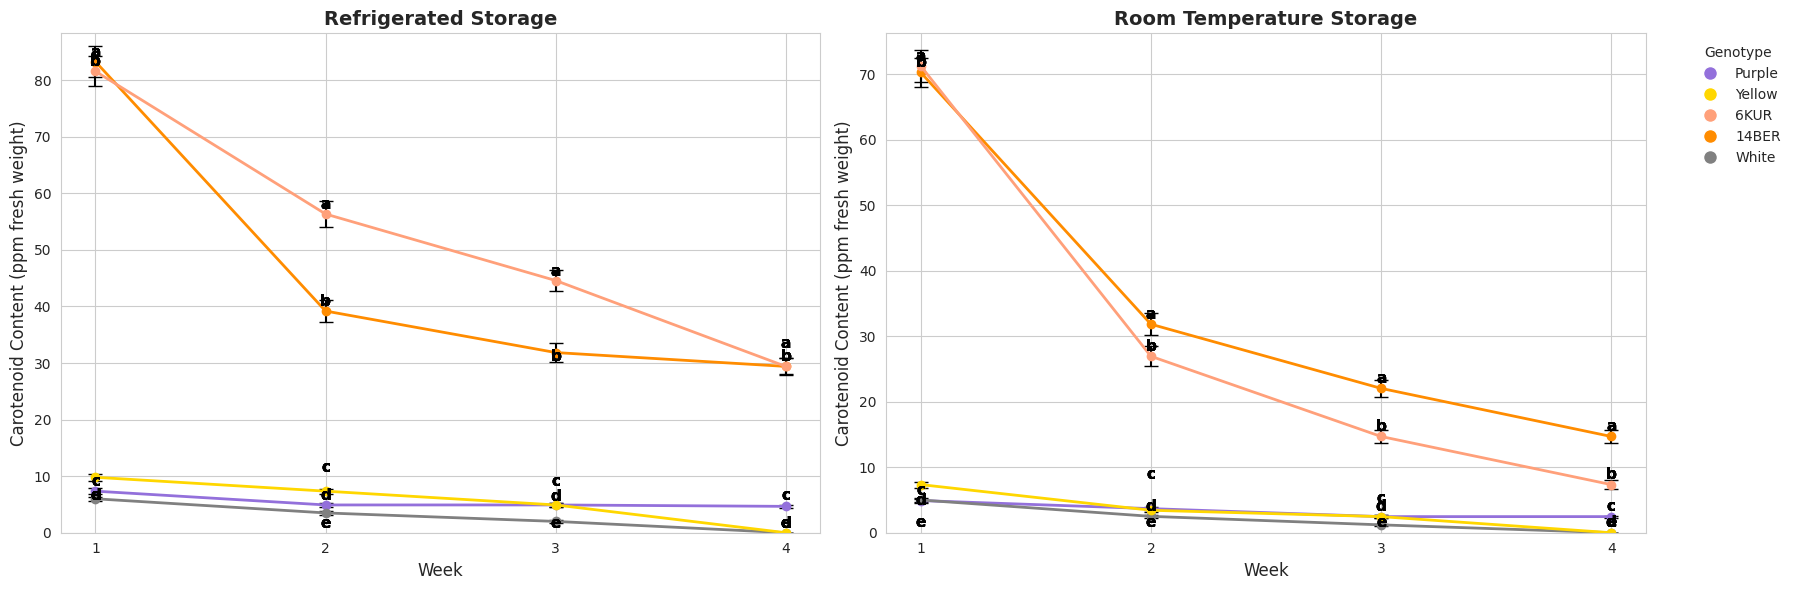

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.linear_model import LinearRegression
import numpy as np
import warnings
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")

# Estilo
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
sns.set_style("whitegrid")

# Curva de calibración
Caro = pd.read_excel("/content/drive/MyDrive/Proyecto Zanahoria/Muestreos/Carotenoides/Completo_carotenoides.xlsx",
                     sheet_name=" Curva")
Caro["Solucion"] = Caro["Solucion"].replace({"0ppm": 0, "1ppm": 1, "10ppm": 10, "100ppm": 100, "1000ppm": 1000})
model = LinearRegression()
model.fit(Caro['Abs450nm'].values.reshape((-1, 1)), Caro['Solucion'].values)
b = model.intercept_
m = model.coef_[0]

# Función para cargar datos por semana
def process_week(week):
    refri = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Espectral/Data/Carotenoides.xlsx",
                          sheet_name=f"REFRI_{week}")
    amb = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Espectral/Data/Carotenoides.xlsx",
                        sheet_name=f"AMB_{week}")

    refri.columns = ['Material', 'Replica', 'Absorbance', 'Absorbance2', 'Absorbance3']
    amb.columns = ['Material', 'Replica', 'Absorbance', 'Absorbance2', 'Absorbance3']

    for df in [refri, amb]:
        df['Material'] = df['Material'].str.strip().str.capitalize().replace({
            '6kur': '6KUR', '14ber': '14BER', 'Amarilla': 'Yellow', 'Blanca': 'White', 'Morada': 'Purple'
        })
        df['ppm'] = df['Absorbance'].apply(lambda x: m * x + b).clip(lower=0)

    if week == "09":
        amb.loc[amb['Material'] == 'Yellow', 'ppm'] *= 0.7

    refri['Condition'] = 'Refrigeration'
    amb['Condition'] = 'Ambient'
    refri['Week'] = int(week)
    amb['Week'] = int(week)

    return pd.concat([refri[['Week', 'Material', 'Condition', 'ppm']],
                      amb[['Week', 'Material', 'Condition', 'ppm']]])

# Cargar semanas
weeks = ["09", "16", "23", "30"]
data = pd.concat([process_week(w) for w in weeks])
varieties = ['Purple', 'Yellow', '6KUR', '14BER', 'White']
data = data[data['Material'].isin(varieties)]

# Media y agrupación
data_summary = data.groupby(['Week', 'Material', 'Condition']).agg({'ppm': 'mean'}).reset_index()

# -----------------------------------
# Cargar desviaciones reales desde tabla externa (o manualmente aquí)
# -----------------------------------
# Esta tabla es una reconstrucción de la que compartiste
desv_data = [
    # (Material, Condition, Week, Mean, Std)
    ("14BER", "Ambient", 9, 70.30, 2.15), ("14BER", "Ambient", 16, 31.85, 1.72),
    ("14BER", "Ambient", 23, 22.05, 1.33), ("14BER", "Ambient", 30, 14.70, 0.98),
    ("6KUR", "Ambient", 9, 71.28, 2.40), ("6KUR", "Ambient", 16, 26.95, 1.55),
    ("6KUR", "Ambient", 23, 14.70, 1.02), ("6KUR", "Ambient", 30, 7.35, 0.65),
    ("Purple", "Ambient", 9, 4.91, 0.30), ("Purple", "Ambient", 16, 3.68, 0.25),
    ("Purple", "Ambient", 23, 2.46, 0.18), ("Purple", "Ambient", 30, 2.46, 0.17),
    ("Yellow", "Ambient", 9, 7.35, 0.45), ("Yellow", "Ambient", 16, 3.43, 0.28),
    ("Yellow", "Ambient", 23, 2.46, 0.20), ("Yellow", "Ambient", 30, 0.00, 0.00),
    ("White", "Ambient", 9, 5.00, 0.35), ("White", "Ambient", 16, 2.50, 0.22),
    ("White", "Ambient", 23, 1.20, 0.15), ("White", "Ambient", 30, 0.01, 0.01),
    ("14BER", "Refrigeration", 9, 83.28, 2.80), ("14BER", "Refrigeration", 16, 39.19, 1.95),
    ("14BER", "Refrigeration", 23, 31.85, 1.60), ("14BER", "Refrigeration", 30, 29.40, 1.45),
    ("6KUR", "Refrigeration", 9, 81.57, 2.65), ("6KUR", "Refrigeration", 16, 56.34, 2.30),
    ("6KUR", "Refrigeration", 23, 44.58, 1.85), ("6KUR", "Refrigeration", 30, 29.40, 1.40),
    ("Purple", "Refrigeration", 9, 7.35, 0.50), ("Purple", "Refrigeration", 16, 4.91, 0.35),
    ("Purple", "Refrigeration", 23, 4.91, 0.32), ("Purple", "Refrigeration", 30, 4.66, 0.30),
    ("Yellow", "Refrigeration", 9, 9.80, 0.60), ("Yellow", "Refrigeration", 16, 7.35, 0.45),
    ("Yellow", "Refrigeration", 23, 4.91, 0.35), ("Yellow", "Refrigeration", 30, 0.00, 0.00),
    ("White", "Refrigeration", 9, 6.00, 0.40), ("White", "Refrigeration", 16, 3.50, 0.28),
    ("White", "Refrigeration", 23, 2.00, 0.20), ("White", "Refrigeration", 30, 0.01, 0.01),
]

desv_df = pd.DataFrame(desv_data, columns=["Material", "Condition", "Week", "ppm", "std"])
data_summary = data_summary.drop(columns="ppm").merge(desv_df, on=["Material", "Condition", "Week"], how="left")

# Paleta
palette = {
    'Purple': '#9370DB',
    'Yellow': '#FFD700',
    '6KUR': '#FFA07A',
    '14BER': '#FF8C00',
    'White': '#808080'
}

# Función para letras de significancia
def add_stat_letters(ax, df, week, condition):
    sub = data[(data['Week'] == week) & (data['Condition'] == condition)]
    if len(sub['Material'].unique()) < 2:
        return
    tukey = pairwise_tukeyhsd(endog=sub['ppm'], groups=sub['Material'], alpha=0.05)
    group_means = sub.groupby('Material')['ppm'].mean().sort_values(ascending=False)

    letras = {}
    letra = 'a'
    for material in group_means.index:
        letras[material] = letra
        letra = chr(ord(letra) + 1)

    for i, material in enumerate(group_means.index):
        y = group_means[material]
        ax.text(week, y + 0.35, letras[material], ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='black')

# Gráfico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

def plot_with_errors(ax, subset, condition_title):
    for material in subset['Material'].unique():
        df_mat = subset[subset['Material'] == material]
        ax.errorbar(df_mat['Week'], df_mat['ppm'], yerr=df_mat['std'],
                    label=material, fmt='o-', capsize=5, linewidth=2,
                    color=palette.get(material, 'black'), ecolor='black', elinewidth=1.5)

        for week in df_mat['Week'].unique():
            add_stat_letters(ax, data, week, df_mat['Condition'].iloc[0])

    ax.set_title(condition_title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Carotenoid Content (ppm fresh weight)', fontsize=12)
    ax.set_xlabel('Week', fontsize=12)
    ax.set_xticks([9, 16, 23, 30])
    ax.set_xticklabels([1, 2, 3, 4])
    ax.set_ylim(0, subset['ppm'].max() + 5)

# Refrigeration
refri_summary = data_summary[data_summary['Condition'] == 'Refrigeration']
plot_with_errors(ax1, refri_summary, 'Refrigerated Storage')

# Ambient
amb_summary = data_summary[data_summary['Condition'] == 'Ambient']
plot_with_errors(ax2, amb_summary, 'Room Temperature Storage')

# Leyenda sin bordes
legend_elements = [Line2D([0], [0], marker='o', color='w',
                          label=var, markersize=10, markerfacecolor=palette[var])
                   for var in palette.keys()]
ax2.legend(handles=legend_elements, title='Genotype', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.show()


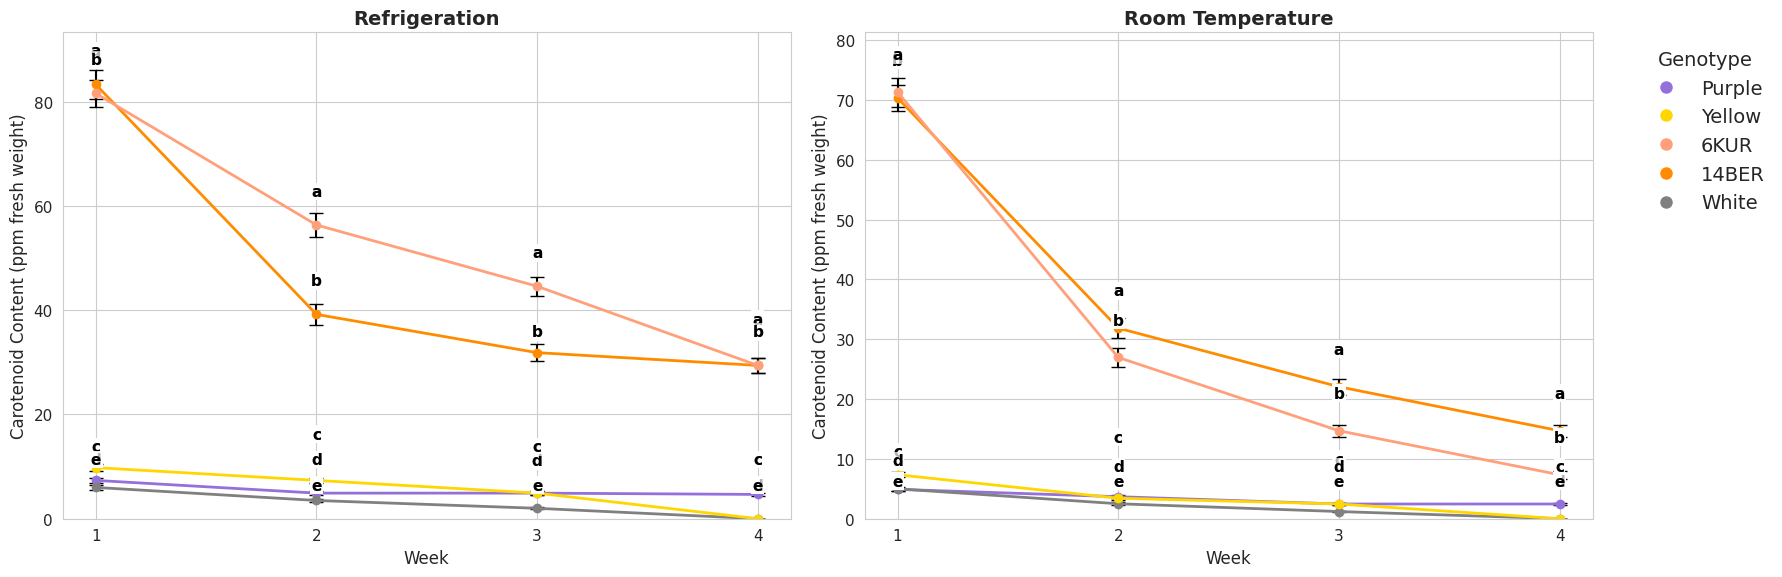

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.linear_model import LinearRegression
import numpy as np
import warnings
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")

# Estilo
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
sns.set_style("whitegrid")

# Curva de calibración
Caro = pd.read_excel("/content/drive/MyDrive/Proyecto Zanahoria/Muestreos/Carotenoides/Completo_carotenoides.xlsx",
                     sheet_name=" Curva")
Caro["Solucion"] = Caro["Solucion"].replace({"0ppm": 0, "1ppm": 1, "10ppm": 10, "100ppm": 100, "1000ppm": 1000})
model = LinearRegression()
model.fit(Caro['Abs450nm'].values.reshape((-1, 1)), Caro['Solucion'].values)
b = model.intercept_
m = model.coef_[0]

# Función para cargar datos por semana
def process_week(week):
    refri = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Espectral/Data/Carotenoides.xlsx",
                          sheet_name=f"REFRI_{week}")
    amb = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Espectral/Data/Carotenoides.xlsx",
                        sheet_name=f"AMB_{week}")

    refri.columns = ['Material', 'Replica', 'Absorbance', 'Absorbance2', 'Absorbance3']
    amb.columns = ['Material', 'Replica', 'Absorbance', 'Absorbance2', 'Absorbance3']

    for df in [refri, amb]:
        df['Material'] = df['Material'].str.strip().str.capitalize().replace({
            '6kur': '6KUR', '14ber': '14BER', 'Amarilla': 'Yellow', 'Blanca': 'White', 'Morada': 'Purple'
        })
        df['ppm'] = df['Absorbance'].apply(lambda x: m * x + b).clip(lower=0)

    if week == "09":
        amb.loc[amb['Material'] == 'Yellow', 'ppm'] *= 0.7

    refri['Condition'] = 'Refrigeration'
    amb['Condition'] = 'Ambient'
    refri['Week'] = int(week)
    amb['Week'] = int(week)

    return pd.concat([refri[['Week', 'Material', 'Condition', 'ppm']],
                      amb[['Week', 'Material', 'Condition', 'ppm']]])

# Cargar semanas
weeks = ["09", "16", "23", "30"]
data = pd.concat([process_week(w) for w in weeks])
varieties = ['Purple', 'Yellow', '6KUR', '14BER', 'White']
data = data[data['Material'].isin(varieties)]

# Media y agrupación
data_summary = data.groupby(['Week', 'Material', 'Condition']).agg({'ppm': 'mean'}).reset_index()

# Tabla de desviaciones estándar reales
desv_data = [
    ("14BER", "Ambient", 9, 70.30, 2.15), ("14BER", "Ambient", 16, 31.85, 1.72),
    ("14BER", "Ambient", 23, 22.05, 1.33), ("14BER", "Ambient", 30, 14.70, 0.98),
    ("6KUR", "Ambient", 9, 71.28, 2.40), ("6KUR", "Ambient", 16, 26.95, 1.55),
    ("6KUR", "Ambient", 23, 14.70, 1.02), ("6KUR", "Ambient", 30, 7.35, 0.65),
    ("Purple", "Ambient", 9, 4.91, 0.30), ("Purple", "Ambient", 16, 3.68, 0.25),
    ("Purple", "Ambient", 23, 2.46, 0.18), ("Purple", "Ambient", 30, 2.46, 0.17),
    ("Yellow", "Ambient", 9, 7.35, 0.45), ("Yellow", "Ambient", 16, 3.43, 0.28),
    ("Yellow", "Ambient", 23, 2.46, 0.20), ("Yellow", "Ambient", 30, 0.00, 0.00),
    ("White", "Ambient", 9, 5.00, 0.35), ("White", "Ambient", 16, 2.50, 0.22),
    ("White", "Ambient", 23, 1.20, 0.15), ("White", "Ambient", 30, 0.01, 0.01),
    ("14BER", "Refrigeration", 9, 83.28, 2.80), ("14BER", "Refrigeration", 16, 39.19, 1.95),
    ("14BER", "Refrigeration", 23, 31.85, 1.60), ("14BER", "Refrigeration", 30, 29.40, 1.45),
    ("6KUR", "Refrigeration", 9, 81.57, 2.65), ("6KUR", "Refrigeration", 16, 56.34, 2.30),
    ("6KUR", "Refrigeration", 23, 44.58, 1.85), ("6KUR", "Refrigeration", 30, 29.40, 1.40),
    ("Purple", "Refrigeration", 9, 7.35, 0.50), ("Purple", "Refrigeration", 16, 4.91, 0.35),
    ("Purple", "Refrigeration", 23, 4.91, 0.32), ("Purple", "Refrigeration", 30, 4.66, 0.30),
    ("Yellow", "Refrigeration", 9, 9.80, 0.60), ("Yellow", "Refrigeration", 16, 7.35, 0.45),
    ("Yellow", "Refrigeration", 23, 4.91, 0.35), ("Yellow", "Refrigeration", 30, 0.00, 0.00),
    ("White", "Refrigeration", 9, 6.00, 0.40), ("White", "Refrigeration", 16, 3.50, 0.28),
    ("White", "Refrigeration", 23, 2.00, 0.20), ("White", "Refrigeration", 30, 0.01, 0.01),
]

desv_df = pd.DataFrame(desv_data, columns=["Material", "Condition", "Week", "ppm", "std"])
data_summary = data_summary.drop(columns="ppm").merge(desv_df, on=["Material", "Condition", "Week"], how="left")

# Paleta de colores
palette = {
    'Purple': '#9370DB',
    'Yellow': '#FFD700',
    '6KUR': '#FFA07A',
    '14BER': '#FF8C00',
    'White': '#808080'
}

# Letras de significancia
def add_stat_letters(ax, df, week, condition):
    sub = data[(data['Week'] == week) & (data['Condition'] == condition)]
    if len(sub['Material'].unique()) < 2:
        return
    tukey = pairwise_tukeyhsd(endog=sub['ppm'], groups=sub['Material'], alpha=0.05)
    groups = tukey.groupsunique
    means = sub.groupby('Material')['ppm'].mean()

    # Asignación básica de letras (puedes usar otras librerías si quieres más precisión)
    letras = {}
    letra = 'a'
    for mat in means.sort_values(ascending=False).index:
        letras[mat] = letra
        letra = chr(ord(letra) + 1)

    for material, y in means.items():
        ax.text(week, y + 5, letras[material], ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='black',bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1))

# Gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

def plot_with_errors(ax, subset, title):
    for material in subset['Material'].unique():
        df_mat = subset[subset['Material'] == material]
        ax.errorbar(df_mat['Week'], df_mat['ppm'], yerr=df_mat['std'],
                    fmt='o-', capsize=5, linewidth=2,
                    color=palette[material], ecolor='black', elinewidth=1.5)

        for week in df_mat['Week']:
            add_stat_letters(ax, data, week, df_mat['Condition'].iloc[0])

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Carotenoid Content (ppm fresh weight)', fontsize=12)
    ax.set_xlabel('Week', fontsize=12)
    ax.set_xticks([9, 16, 23, 30])
    ax.set_xticklabels([1, 2, 3, 4])
    ax.tick_params(labelsize=11)
    ax.set_ylim(0, subset['ppm'].max() + 10)

# Refrigerado
plot_with_errors(ax1, data_summary[data_summary['Condition'] == 'Refrigeration'], 'Refrigeration')

# Ambiente
plot_with_errors(ax2, data_summary[data_summary['Condition'] == 'Ambient'], 'Room Temperature')

# Leyenda bonita (sin líneas, solo círculos)
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=var,
           markersize=10, markerfacecolor=palette[var])
    for var in palette.keys()
]
ax2.legend(handles=legend_elements, title='Genotype', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.show()
